# İŞ emri raporu keşifçi veri analizi

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

import numpy as np
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings("ignore")


## 2022-2023-2024 İŞ EMRİ RAPORU_OTOBB

In [544]:
FILE_PATH = "2022-2023-2024 İŞ EMRİ RAPORU_CANTER.csv"
df_canter = pd.read_csv(FILE_PATH)

In [112]:
FILE_PATH = "2022-2023-2024 İŞ EMRİ RAPORU_OTOBB.csv"
df_otob = pd.read_csv(FILE_PATH)

In [189]:
cols_df_4000 = set(df_canter.columns)
cols_df_5000 = set(df_otob.columns)

only_in_df_4000 = cols_df_4000 - cols_df_5000
only_in_df_5000 = cols_df_5000 - cols_df_4000

print("canter'de olup otob'da olmayan kolonlar:", only_in_df_4000)
print("otob'da olup canter'de olmayan kolonlar:", only_in_df_5000)

canter'de olup otob'da olmayan kolonlar: {'Filo ?', 'Personel Adı', 'Fatura Türü', 'Miktar', 'İşlem Kodu', 'İş Emri No', 'Açıklama', 'Adı', 'İş Emri Tar.', 'Telefon.1', 'Durum', 'Bakım ?', 'Garantide mi?', 'İşlem Türü', 'TCKN/VKN', 'Temsa Aracı mı?', 'Kategori', 'Güncel Kod', 'Motor No', 'Kmp. No', 'Teslim Alan', 'İş Emrini Açan', 'Mess Üyesi', 'KM', 'Tutar', 'Şasi', 'Birim Fiyat', 'İndirim', 'Teknisten Adı', 'Kaynak', 'Kodu', 'Unnamed: 39', 'E.S ?', 'Adı.1', 'Model Yılı', 'Kapanış Tar.', 'Fatura ?', 'Telefon'}
otob'da olup canter'de olmayan kolonlar: {'Temsa / Temsa dışı', 'Çıkış Tarihi', 'Bayi Adı', 'Unnamed: 18', 'Bayi Kod', 'İ.E.Tip', 'İş Emri', 'Model Kod', 'Km', 'Temsa Kodu', 'Parça Kodu', 'Fiyat', 'Ana Model', 'Şase No', 'Yıl', 'Model Yıl', 'Garanti Dışı', 'Firma Adı', 'Temsa Güncel Kod', 'Ay', 'Verilen Miktar', 'Giriş Tarihi'}


In [185]:
df_canter

,Kodu,Adı,İş Emri Tar.,Kapanış Tar.,İş Emri No,Durum,KM,İş Emrini Açan,Mess Üyesi,Adı.1,Telefon,TCKN/VKN,Model Adı,Model Yılı,İşlem Türü,Kaynak,İşlem Kodu,Güncel Kod,Açıklama,Birim Fiyat,Miktar,İndirim,Tutar,Kmp. No,Bakım ?,Fatura ?,Filo ?,E.S ?,Personel Adı,Teknisten Adı,Fatura Türü,Kategori,Şasi,Plaka,Motor No,Temsa Aracı mı?,Teslim Alan,Telefon.1,Garantide mi?,Unnamed: 39
0,600030,Bayraktar,1.01.2022,1.01.2022,101465,Kapalı,182104,FATMA CİHAN,False,ÜÇYILDIZ MOBİLYA İMALAT İTHALAT İHRACAT SAN.VE TİC.LTD.ŞTİ.,905495485461.0,9050236374.0,CANTER,2015,Parça,Temsa Dışı,MY5W30C2,MY5W30C2,5W30 MOTOR YAĞI,₺80.00,6.5,0.0,₺520.00,NaN,False,True,False,False,NaN,NaN,Müşteri,Mekanik,NLTFEB21C01000536,54BF351,2357529,Temsa Aracı,AYDIN BAŞARAN,905495485461,Hayır,NaN
1,600030,Bayraktar,1.01.2022,1.01.2022,101465,Kapalı,182104,FATMA CİHAN,False,ÜÇYILDIZ MOBİLYA İMALAT İTHALAT İHRACAT SAN.VE TİC.LTD.ŞTİ.,905495485461.0,9050236374.0,CANTER,2015,Parça,Temsa,QC000001Y,QC000001Y,"FILTRE, YAG",₺74.45,1.0,10.0,₺67.00,NaN,False,True,False,False,NaN,NaN,Müşteri,Mekanik,NLTFEB21C01000536,54BF351,2357529,Temsa Aracı,AYDIN BAŞARAN,905495485461,Hayır,NaN
2,600030,Bayraktar,1.01.2022,1.01.2022,101465,Kapalı,182104,FATMA CİHAN,False,ÜÇYILDIZ MOBİLYA İMALAT İTHALAT İHRACAT SAN.VE TİC.LTD.ŞTİ.,905495485461.0,9050236374.0,CANTER,2015,Parça,Temsa Dışı,ML239124.,ML239124.,"FİLTRE, YAKIT",₺110.19,1.0,10.0,₺99.17,NaN,False,True,False,False,NaN,NaN,Müşteri,Mekanik,NLTFEB21C01000536,54BF351,2357529,Temsa Aracı,AYDIN BAŞARAN,905495485461,Hayır,NaN
3,600030,Bayraktar,1.01.2022,1.01.2022,101465,Kapalı,182104,FATMA CİHAN,False,ÜÇYILDIZ MOBİLYA İMALAT İTHALAT İHRACAT SAN.VE TİC.LTD.ŞTİ.,905495485461.0,9050236374.0,CANTER,2015,Parça,Temsa Dışı,ML242294.,ML242294.,HAVA FİLTRESİ,₺263.60,1.0,9.9,₺237.50,NaN,False,True,False,False,NaN,NaN,Müşteri,Mekanik,NLTFEB21C01000536,54BF351,2357529,Temsa Aracı,AYDIN BAŞARAN,905495485461,Hayır,NaN
4,600030,Bayraktar,1.01.2022,4.01.2022,101464,Kapalı,384036,FATMA CİHAN,False,MEHTİ DUMAN,905352353928.0,34624629422.0,CANTER,2008,Parça,Temsa,TE215002Y,TE215002Y,"FİLTRE,YAĞ",₺103.69,1.0,10.0,₺93.32,NaN,False,True,False,False,NaN,NaN,Müşteri,Mekanik,NLTFE85PG01001421,11AAK250,4D34-L51783,Temsa Aracı,İHSAN DUMAN,905352353928,Hayır,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372391,601109,Yıldızlar,28.02.2025,28.02.2025,110084,Kapalı,21089,MURAT ÇETİNDERE,False,ESLAB KAHVE GIDA SANAYİ VE TİCARET ANONİM ŞİRKETİ,905078746449.0,3800537841.0,CANTER,2024,Parça,Temsa Dışı,AMP1,NaN,AMPUL,₺125.00,4.0,5.0,₺475.00,NaN,False,True,False,False,NaN,NaN,Müşteri,Mekanik,NLTTECX1G01001927,34MEF141,4629085,Temsa Aracı,YILMAZ ÖZTÜRK,905384944336.0,Evet,NaN
372392,601109,Yıldızlar,28.02.2025,28.02.2025,110083,Kapalı,98195,MURAT ÇETİNDERE,False,BEDA ENERJİ DAĞITIM VE PERAKENDE SATIŞ HİZMETLERİ ANONİM ŞİRKETİ,905074255677.0,1600670174.0,CANTER,2021,Parça,Temsa Dışı,MK580527-ALT,NaN,FAR ÜSTÜ SİNYAL SOL,"₺1,500.00",1.0,10.0,"₺1,350.00",NaN,False,True,True,False,NaN,NaN,Müşteri,Mekanik,NLTTEB91G01000521,06CKZ884,4026366,Temsa Aracı,ÜMİT TOPRAK,905544840815.0,Hayır,NaN
372393,601109,Yıldızlar,28.02.2025,28.02.2025,110083,Kapalı,98195,MURAT ÇETİNDERE,False,BEDA ENERJİ DAĞITIM VE PERAKENDE SATIŞ HİZMETLERİ ANONİM ŞİRKETİ,905074255677.0,1600670174.0,CANTER,2021,Parça,Temsa,MK486111,NaN,AYNA ISITMALI,"₺2,880.71",1.0,10.0,"₺2,592.64",NaN,False,True,True,False,NaN,NaN,Müşteri,Mekanik,NLTTEB91G01000521,06CKZ884,4026366,Temsa Aracı,ÜMİT TOPRAK,905544840815.0,Hayır,NaN
372394,601109,Yıldızlar,28.02.2025,28.02.2025,110083,Kapalı,98195,MURAT ÇETİNDERE,False,BEDA ENERJİ DAĞITIM VE PERAKENDE SATIŞ HİZMETLERİ ANONİM ŞİRKETİ,905074255677.0,1600670174.0,CANTER,2021,Parça,Temsa,FE802165Y,NaN,E5 STOP SAĞ SOL,"₺2,925.88",2.0,10.0,"₺5,266.58",NaN,False,True,True,False,NaN,NaN,Müşteri,Mekanik,NLTTEB91G01000521,06CKZ884,4026366,Temsa Aracı,ÜMİT TOPRAK,905544840815.0,Hay

In [90]:
df_otob.head()

,Bayi Kod,Çıkış Tarihi,Şase No,Km,İş Emri,İ.E.Tip,Parça Kodu,Temsa / Temsa dışı,Temsa Kodu,Temsa Güncel Kod,Garanti Dışı,Verilen Miktar,Fiyat,Firma Adı,Bayi Adı,Model Kod,Model Yıl,Ana Model,Unnamed: 18,Model Adı,Giriş Tarihi,Yıl,Ay,Plaka
0,600023,2022-06-30,NLTNVSF6L01000162,"706,450.00",236019,A,0001231016-ALT,TEMSA DIŞI,0001231016,0001231016,Garanti Dışı,1.0,"4,585.00",SVS TAŞIMACILIK ARAÇ KİRALAMA TİCARET,ATASER,OBAVE02,2012,AVENUE,NaN,AVENUE LF,2022-06-28,2022,Haziran,34HK3373
1,600023,2023-05-24,NLTNVSF6L01000090,"841,414.00",239424,Y,0001231016-ALT,TEMSA DIŞI,0001231016,0001231016,Garanti Dışı,1.0,"7,000.00",COŞKUNLAR HALK OTOBÜS İŞLETMECİLİĞİ,ATASER,OBAVE02,2012,AVENUE,NaN,AVENUE LF,2023-05-18,2023,Mayıs,34HO2476
2,601083,2023-02-15,NLTRHUA8L01010133,"1,983,210.00",65095,A,0001261069,TEMSA,NaN,0001261069,Garanti Dışı,1.0,"11,694.92",ÇETUR ÇELEBİ TURİZM İNŞAAT SAN. VE TİC.A.Ş.,TAŞMER OTOMOTİV,OBSAF45,2013,SAFIR,NaN,SAFIR 13M DAF E5 410PS CS ORME,2023-02-15,2023,Şubat,07AVC216
3,601058,2024-08-15,NLTRHUA8L01010468,"599,610.00",3619,A,0001261085,TEMSA,NaN,0001261085,Garanti Dışı,1.0,"15,843.66",METRO TURİZM SEYAHAT ORGANİZASYON,ÖZPAM MUĞLA,OBSAF68,2015,SAFIR,NaN,SAFIR VIP 13 DAF E5 410PS CS DÜZTABAN,2024-01-08,2024,Ocak,34BK6820
4,600865,2023-08-02,NLTRJU98L01010089,"850,000.00",30207,A,0001261087,TEMSA,NaN,0001261087,Garanti Dışı,1.0,"15,307.15",DEVALP TURİZM TAŞIMACILIK KURUMSAL HİZMETLER,ASKAR BURSA,OBSAF22,2010,SAFİR,NaN,SAFIR 13 DAF E4 410PS SS ÖRME YURT İÇİ,2023-08-01,2023,Ağustos,16S2540


In [88]:
date_cols = [
    "Çıkış Tarihi",
    "Giriş Tarihi",
   
]

for col in date_cols:
        df_otob[col] = pd.to_datetime(df_otob[col], errors='coerce', dayfirst=True)
        print(f"🗓️ '{col}' sütunu datetime formatına çevrildi.")

🗓️ 'Çıkış Tarihi' sütunu datetime formatına çevrildi.
🗓️ 'Giriş Tarihi' sütunu datetime formatına çevrildi.


In [120]:
kolonlar = [
    "Bayi Kod",
    "Çıkış Tarihi",
    "Şase No",
    "Km",
    "İş Emri",
    "İ.E.Tip",
    "Parça Kodu",
    "Temsa / Temsa dışı",
    "Temsa Kodu",
    "Temsa Güncel Kod",
    "Garanti Dışı",
    "Verilen Miktar",
    "Fiyat",
    "Firma Adı",
    "Bayi Adı",
    "Model Kod",
    "Model Yıl",
    "Ana Model",
    "Unnamed: 18",      
    "Model Adı",
    "Giriş Tarihi",
    "Yıl",
    "Ay",
    "Plaka",
]


In [122]:
# 1) Başlıkları temizle (gizli boşluk, NBSP, vb.)
import unicodedata as ud
df_otob.columns = df_otob.columns.map(lambda s: ud.normalize("NFKC", s).strip())

# 2) Tarih, sayısal ve kategorik alanları ayır
date_cols   = ["Çıkış Tarihi", "Giriş Tarihi"]
numeric_cols = ["Km", "Verilen Miktar", "Fiyat",]
cat_cols    = [c for c in kolonlar if c not in date_cols + numeric_cols]

# 3) Tip dönüşümleri
df_otob[date_cols]   = df_otob[date_cols].apply(pd.to_datetime, errors="coerce", dayfirst=True)
df_otob[numeric_cols] = df_otob[numeric_cols].apply(pd.to_numeric, errors="coerce")
df_otob[cat_cols]     = df_otob[cat_cols].astype("category")

In [110]:
df_otob

,Bayi Kod,Çıkış Tarihi,Şase No,Km,İş Emri,İ.E.Tip,Parça Kodu,Temsa / Temsa dışı,Temsa Kodu,Temsa Güncel Kod,Garanti Dışı,Verilen Miktar,Fiyat,Firma Adı,Bayi Adı,Model Kod,Model Yıl,Ana Model,Unnamed: 18,Model Adı,Giriş Tarihi,Yıl,Ay,Plaka
0,600023,2022-06-30,NLTNVSF6L01000162,"706,450.00",236019,A,0001231016-ALT,TEMSA DIŞI,0001231016,0001231016,Garanti Dışı,1.0,"4,585.00",SVS TAŞIMACILIK ARAÇ KİRALAMA TİCARET,ATASER,OBAVE02,2012,AVENUE,NaN,AVENUE LF,2022-06-28,2022,Haziran,34HK3373
1,600023,2023-05-24,NLTNVSF6L01000090,"841,414.00",239424,Y,0001231016-ALT,TEMSA DIŞI,0001231016,0001231016,Garanti Dışı,1.0,"7,000.00",COŞKUNLAR HALK OTOBÜS İŞLETMECİLİĞİ,ATASER,OBAVE02,2012,AVENUE,NaN,AVENUE LF,2023-05-18,2023,Mayıs,34HO2476
2,601083,2023-02-15,NLTRHUA8L01010133,"1,983,210.00",65095,A,0001261069,TEMSA,NaN,0001261069,Garanti Dışı,1.0,"11,694.92",ÇETUR ÇELEBİ TURİZM İNŞAAT SAN. VE TİC.A.Ş.,TAŞMER OTOMOTİV,OBSAF45,2013,SAFIR,NaN,SAFIR 13M DAF E5 410PS CS ORME,2023-02-15,2023,Şubat,07AVC216
3,601058,2024-08-15,NLTRHUA8L01010468,"599,610.00",3619,A,0001261085,TEMSA,NaN,0001261085,Garanti Dışı,1.0,"15,843.66",METRO TURİZM SEYAHAT ORGANİZASYON,ÖZPAM MUĞLA,OBSAF68,2015,SAFIR,NaN,SAFIR VIP 13 DAF E5 410PS CS DÜZTABAN,2024-01-08,2024,Ocak,34BK6820
4,600865,2023-08-02,NLTRJU98L01010089,"850,000.00",30207,A,0001261087,TEMSA,NaN,0001261087,Garanti Dışı,1.0,"15,307.15",DEVALP TURİZM TAŞIMACILIK KURUMSAL HİZMETLER,ASKAR BURSA,OBSAF22,2010,SAFİR,NaN,SAFIR 13 DAF E4 410PS SS ÖRME YURT İÇİ,2023-08-01,2023,Ağustos,16S2540
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
655000,601058,2025-03-12,NLTRTUK8L01000147,"2,434,995.00",4780,A,D2000085-ALT01,TEMSA DIŞI,D2000085,D2000085,Garanti Dışı,NaN,"10,500.00",ARVEM FARMA SAĞLIK MEDİKAL GIDA TEKSTİL,ÖZPAM MUĞLA,OBMAR11,2017,MARATON,NaN,MARATON 13 DAF E6 435PS/320KW CS,2025-02-24,2025,Şubat,20AJB907
655001,601058,2025-03-12,NLTRTUK8L01000147,"2,434,995.00",4780,A,D2203568-ALT01,TEMSA DIŞI,D2203568,D2203568,Garanti Dışı,1.0,"10,500.00",ARVEM FARMA SAĞLIK MEDİKAL GIDA TEKSTİL,ÖZPAM MUĞLA,OBMAR11,2017,MARATON,NaN,MARATON 13 DAF E6 435PS/320KW CS,2025-02-24,2025,Şubat,20AJB907
655002,601058,2025-03-12,NLTRTUK8L01000147,"2,434,995.00",4780,A,D2206218-ALT01,TEMSA DIŞI,D2206218,D2206218,Garanti Dışı,NaN,"14,000.00",ARVEM FARMA SAĞLIK MEDİKAL GIDA TEKSTİL,ÖZPAM MUĞLA,OBMAR11,2017,MARATON,NaN,MARATON 13 DAF E6 435PS/320KW CS,2025-02-24,2025,Şubat,20AJB907
655003,601058,2025-03-12,NLTRTUK8L01000147,"2,434,995.00",4780,A,D2317876-ALT01,TEMSA DIŞI,D2317876,D2317876,Garanti Dışı,NaN,"25,000.02",ARVEM FARMA SAĞLIK MEDİKAL GIDA TEKSTİL,ÖZPAM MUĞLA,OBMAR11,2017,MARATON,NaN,MARATON 13 DAF E6 435PS/320KW CS,2025-02-24,2025,Şubat,20AJB907


In [124]:
df_otob.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 655005 entries, 0 to 655004
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Bayi Kod            655005 non-null  category      
 1   Çıkış Tarihi        642681 non-null  datetime64[ns]
 2   Şase No             655005 non-null  category      
 3   Km                  172 non-null     float64       
 4   İş Emri             655005 non-null  category      
 5   İ.E.Tip             655005 non-null  category      
 6   Parça Kodu          655005 non-null  category      
 7   Temsa / Temsa dışı  655005 non-null  category      
 8   Temsa Kodu          414968 non-null  category      
 9   Temsa Güncel Kod    655005 non-null  category      
 10  Garanti Dışı        655005 non-null  category      
 11  Verilen Miktar      622939 non-null  float64       
 12  Fiyat               502580 non-null  float64       
 13  Firma Adı           654538 no

## df_otob null değer analizi

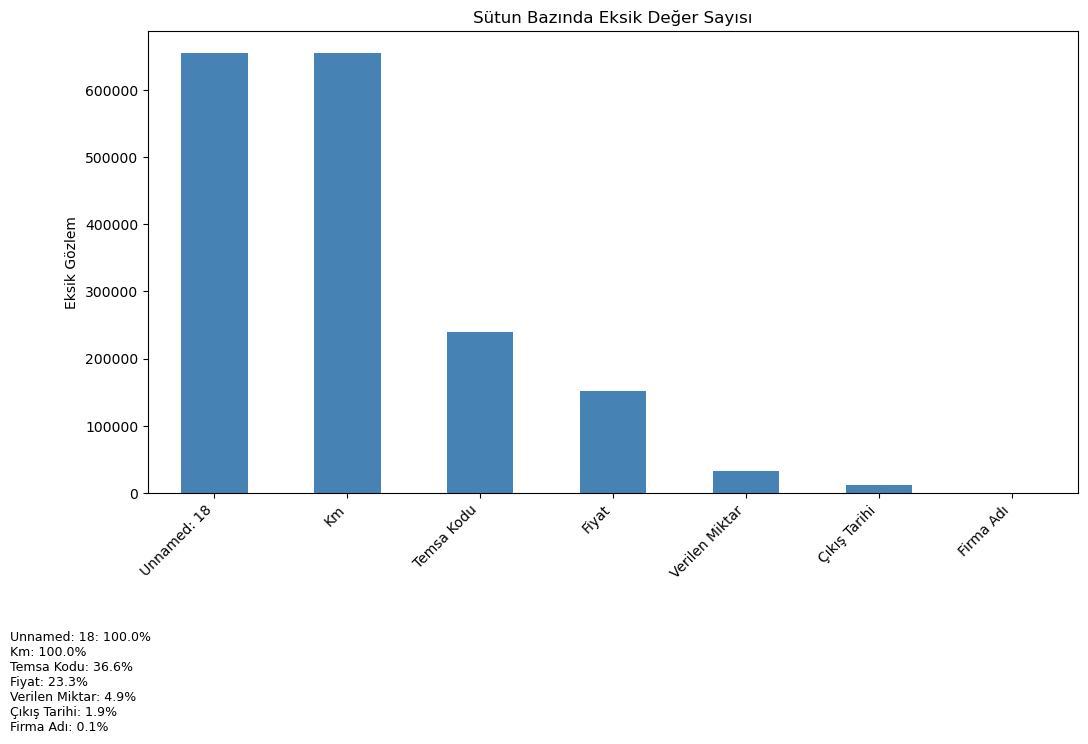

In [556]:
null_counts = df_otob.isna().sum()
null_perc   = null_counts / len(df_otob) * 100

null_stats = (
    pd.DataFrame({"Eksik Sayısı": null_counts, "Yüzde (%)": null_perc})
      .query("`Eksik Sayısı` > 0")                    # tamamen dolu sütunları at
      .sort_values("Eksik Sayısı", ascending=False)
)

# -------------------------------------------------
# 3) Grafik
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))
null_stats["Eksik Sayısı"].plot(kind="bar", ax=ax, color="steelblue")

ax.set_title("Sütun Bazında Eksik Değer Sayısı")
ax.set_ylabel("Eksik Gözlem")
ax.set_xticklabels(null_stats.index, rotation=45, ha="right")

# -------------------------------------------------
# 4) Yüzdeleri toplu hâlde grafiğin altına yaz
# -------------------------------------------------
# • Yazılacak metni satır satır oluştur
yuzde_metni = "\n".join(
    f"{col}: {pct:.1f}%" for col, pct in null_stats["Yüzde (%)"].items()
)

# • Figürün içine, grafiğin altına sola hizalı şekilde yerleştir
fig.text(0.01, -0.12, yuzde_metni, ha="left", va="top", fontsize=9)

plt.show()

#### soru 1) unnamed 18 neyi temsil etmektedir neden hepsi boştur?

In [158]:
mask = df_otob["Temsa Kodu"].isna()
df_temsa_bos = df_otob[mask]
df_temsa_bos

,Bayi Kod,Çıkış Tarihi,Şase No,Km,İş Emri,İ.E.Tip,Parça Kodu,Temsa / Temsa dışı,Temsa Kodu,Temsa Güncel Kod,Garanti Dışı,Verilen Miktar,Fiyat,Firma Adı,Bayi Adı,Model Kod,Model Yıl,Ana Model,Unnamed: 18,Model Adı,Giriş Tarihi,Yıl,Ay,Plaka
2,601083,2023-02-15,NLTRHUA8L01010133,NaN,65095,A,0001261069,TEMSA,NaN,0001261069,Garanti Dışı,1.0,NaN,ÇETUR ÇELEBİ TURİZM İNŞAAT SAN. VE TİC.A.Ş.,TAŞMER OTOMOTİV,OBSAF45,2013,SAFIR,NaN,SAFIR 13M DAF E5 410PS CS ORME,2023-02-15,2023,Şubat,07AVC216
3,601058,2024-08-15,NLTRHUA8L01010468,NaN,3619,A,0001261085,TEMSA,NaN,0001261085,Garanti Dışı,1.0,NaN,METRO TURİZM SEYAHAT ORGANİZASYON,ÖZPAM MUĞLA,OBSAF68,2015,SAFIR,NaN,SAFIR VIP 13 DAF E5 410PS CS DÜZTABAN,2024-01-08,2024,Ocak,34BK6820
4,600865,2023-08-02,NLTRJU98L01010089,NaN,30207,A,0001261087,TEMSA,NaN,0001261087,Garanti Dışı,1.0,NaN,DEVALP TURİZM TAŞIMACILIK KURUMSAL HİZMETLER,ASKAR BURSA,OBSAF22,2010,SAFİR,NaN,SAFIR 13 DAF E4 410PS SS ÖRME YURT İÇİ,2023-08-01,2023,Ağustos,16S2540
17,600023,2024-09-26,NLTNVSF6L01000185,NaN,244964,Y,0001263006,TEMSA,NaN,0001263006,Garanti Dışı,1.0,NaN,ANIL ERTUNÇ OTOBÜS,ATASER,OBAVE02,2012,AVENUE,NaN,AVENUE LF,2024-09-23,2024,Eylül,34HO2620
19,600023,2024-12-12,NLTNVSF6L01000678,NaN,245797,A,0001263006,TEMSA,NaN,0001263006,Garanti Dışı,1.0,NaN,HİKMET POLAT,ATASER,OBAVE09,2014,AVENUE,NaN,AVENUE LF 12M CS CUMMINS E5 285PS,2024-12-12,2024,Aralık,34DJR334
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
653993,601083,2025-02-12,NLTRJT98L01010029,NaN,70665,A,ZR905Z,TEMSA,NaN,ZR905Z,Garanti Dışı,NaN,NaN,AKSU BİRLİK TUR. TAŞ.LTD.ŞTİ.,TAŞMER OTOMOTİV,OBSAF25,2010,SAFİR,NaN,SAFIR 12.2 DAF E4 410PS SS ÖRME YURT İÇI,2025-02-10,2025,Şubat,07AAT022
653994,601083,2025-02-14,NLTRHTA8L01010209,NaN,70691,A,ZR905Z,TEMSA,NaN,ZR905Z,Garanti Dışı,NaN,NaN,MYTOURANTALYA TURZ. TAŞ. SEY. ACENT.,TAŞMER OTOMOTİV,OBSAF54,2014,SAFIR,NaN,SAFIR 12.2 DAF E5 410 PS SS ÖRME YURTİÇİ,2025-02-14,2025,Şubat,07CAF441
653995,601083,2025-02-19,NLTRHTA8L01010298,NaN,70692,A,ZR905Z,TEMSA,NaN,ZR905Z,Garanti Dışı,NaN,NaN,TOURAMA YOLCU TAŞIMACILIĞI VE TURZ. A.Ş.,TAŞMER OTOMOTİV,OBSAF69,2015,SAFIR,NaN,"SAFIR 12.2 DAF E5 410PS ÖRME,YURT İÇİ",2025-02-14,2025,Şubat,07D5758
653996,601058,2025-02-13,NLTRHTA8L01010287,NaN,4711,A,ZR905Z,TEMSA,NaN,ZR905Z,Garanti Dışı,NaN,NaN,MUTTAŞ MUĞLA KENT HİZM.TAŞIMACILIK EĞİTİM,ÖZPAM MUĞLA,OBSAF54,2015,SAFIR,NaN,SAFIR 12.2 DAF E5 410 PS SS ÖRME YURTİÇİ,2025-02-03,2025,Şubat,48EB264


In [160]:
null_cols = df_temsa_bos.isna().sum().sort_values(ascending=False)
print(null_cols[null_cols > 0]) 

Unnamed: 18       240037
Temsa Kodu        240037
Km                239939
Fiyat              87470
Verilen Miktar     12692
Çıkış Tarihi        5039
Firma Adı            321
dtype: int64


In [162]:
print(239939/240037)#nan temsa kod/(nan km

0.9995917296083521


#### soru2) temsa kodunun boş olması neyi ifade etmektedir.Temsa kodunun boş olmasının km ile bir ilişkisi var mıdır?

## kategorik veri analizi

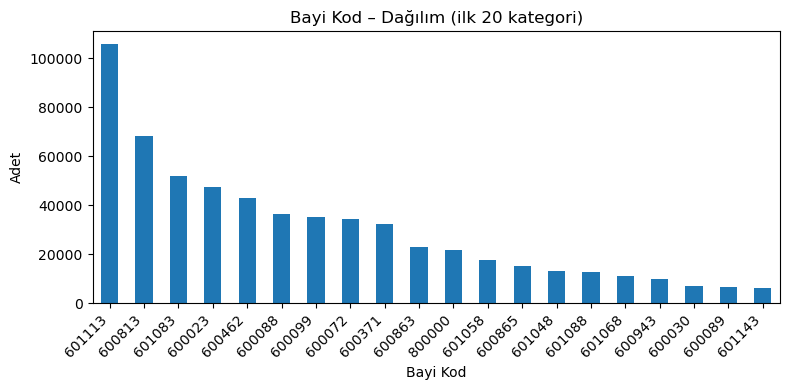

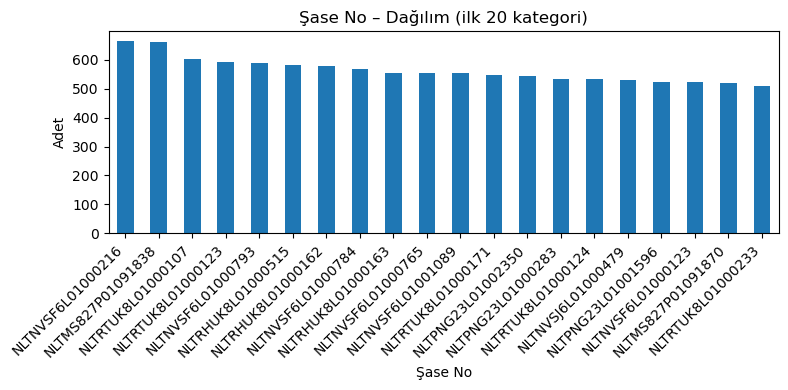

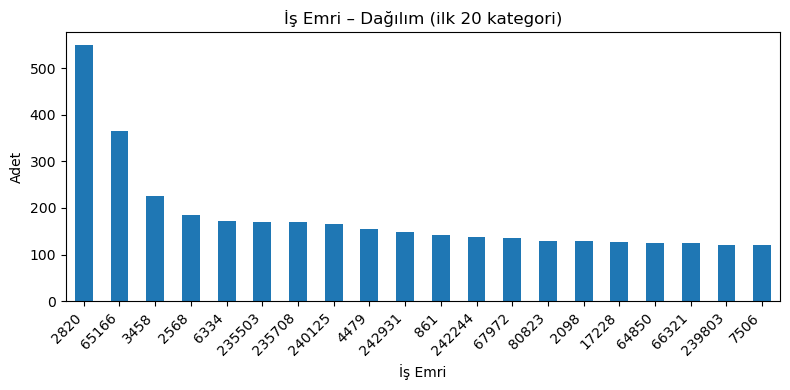

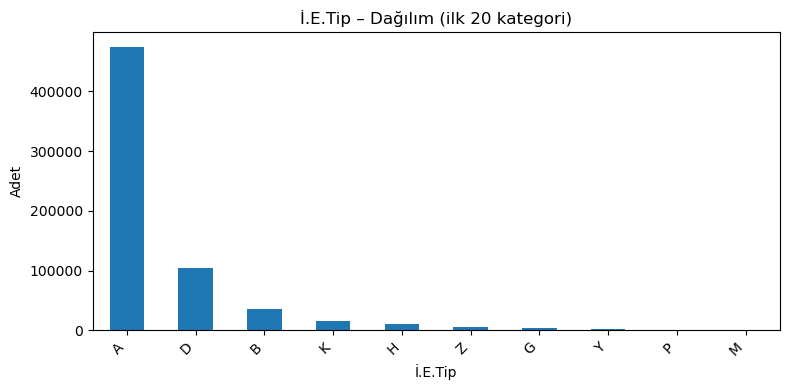

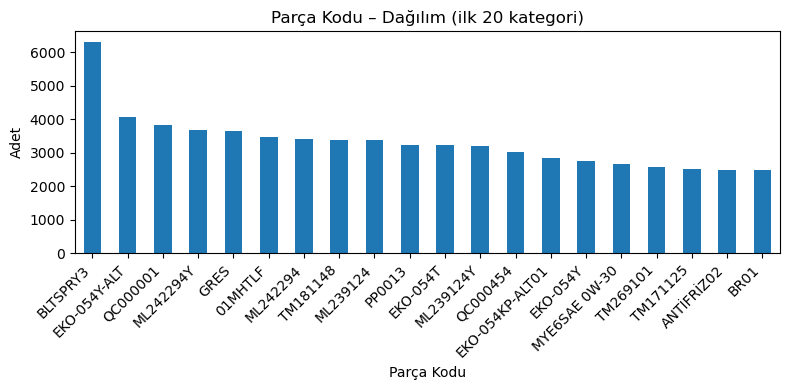

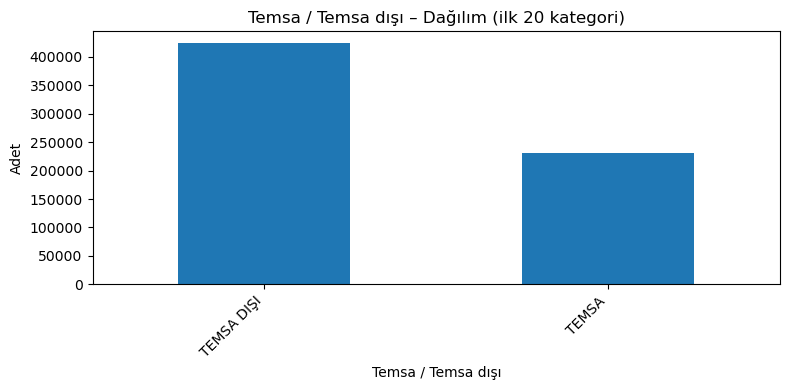

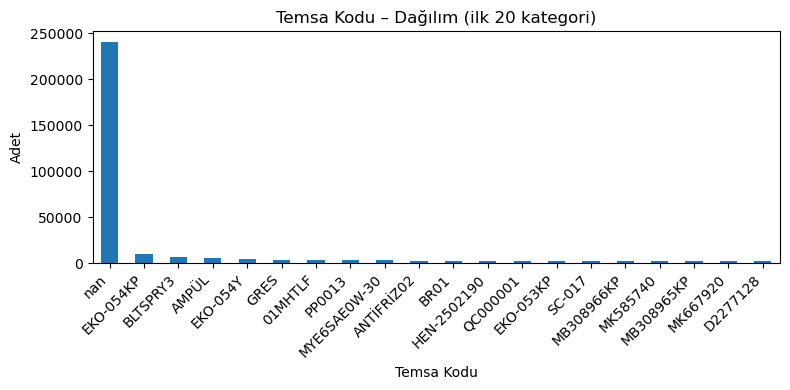

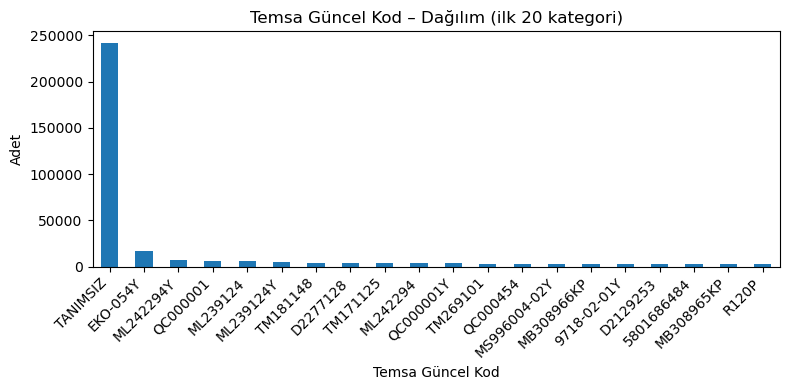

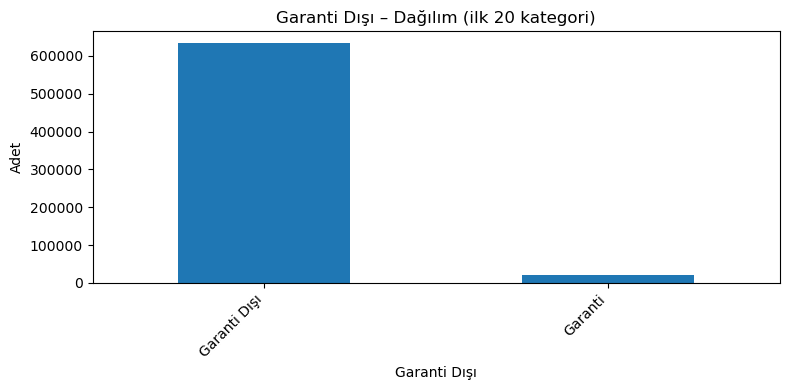

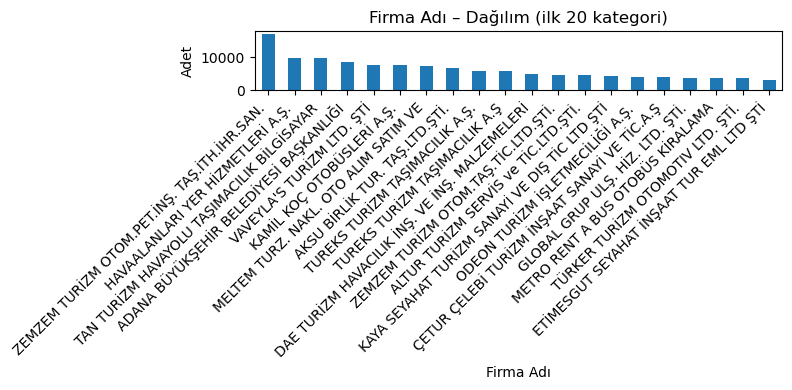

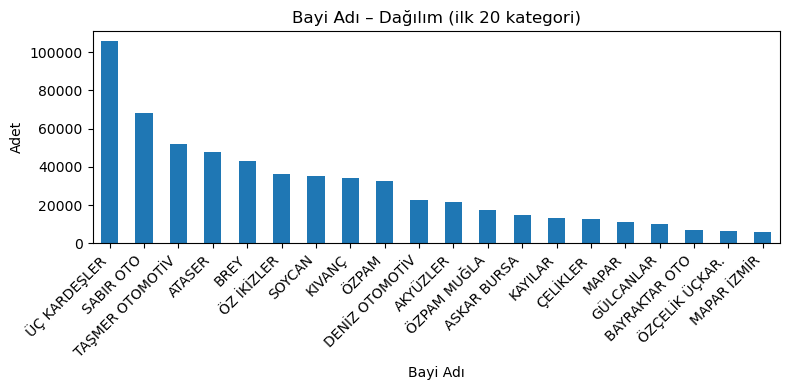

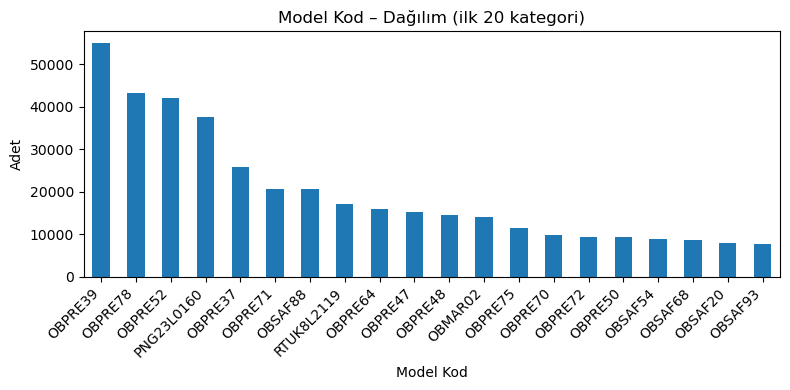

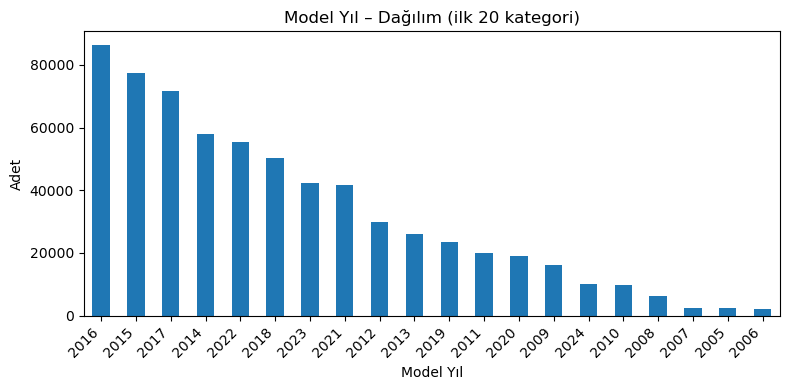

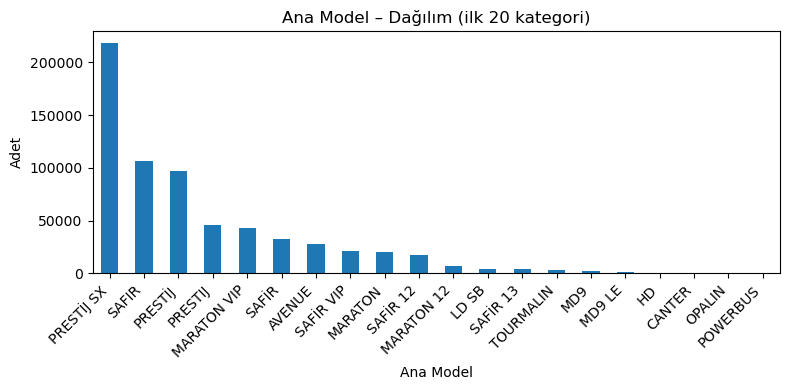

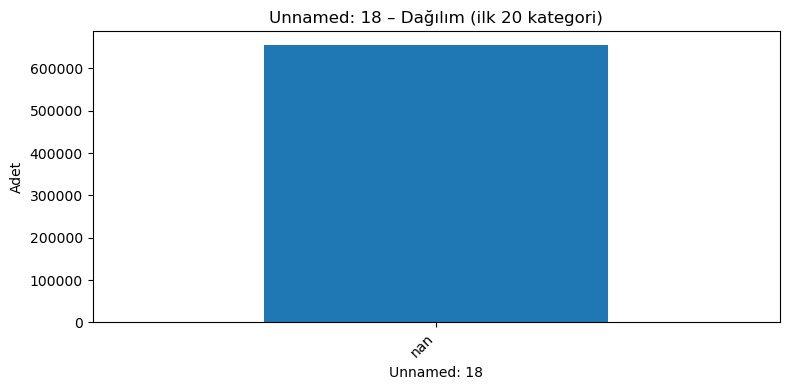

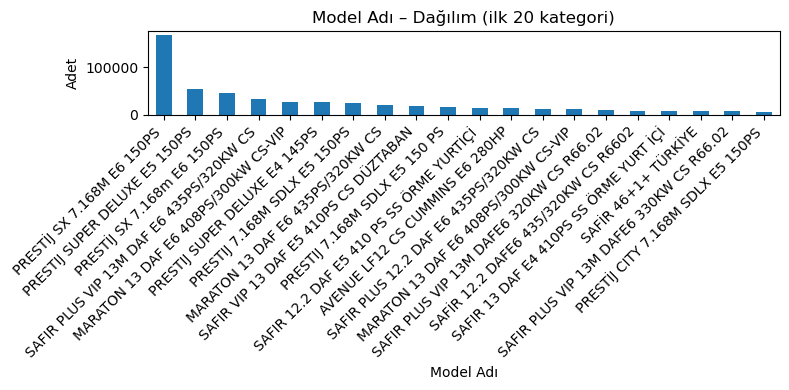

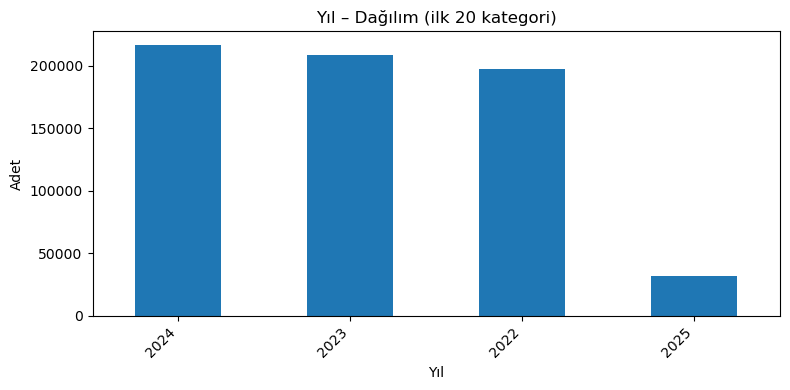

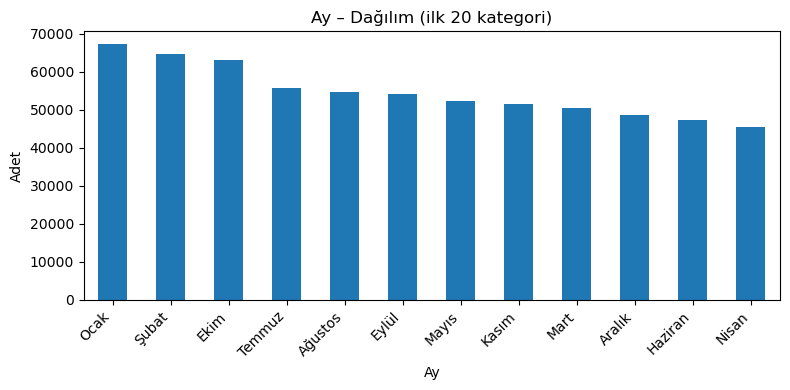

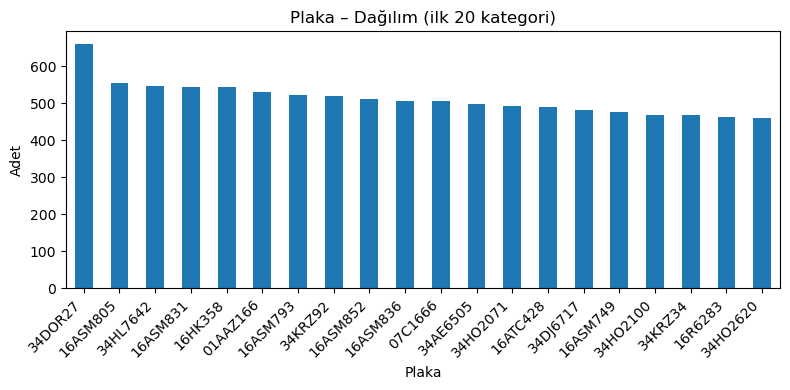

In [580]:

# -----------------------------------------
cat_cols = df_otob.select_dtypes(include=["category"]).columns.tolist()


# -----------------------------------------
# 2) Sırayla çiz
# -----------------------------------------
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    # Çok kalabalık kolonlar için en fazla ilk 20 kategoriyi çizdiriyoruz
    df_otob[col].value_counts(dropna=False).head(20).plot(kind="bar")
    plt.title(f"{col} – Dağılım (ilk 20 kategori)")
    plt.ylabel("Adet")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

### Garanti dışı

In [322]:
df_otob[df_otob["Garanti Dışı"]=="Garanti"]

,Bayi Kod,Çıkış Tarihi,Şase No,Km,İş Emri,İ.E.Tip,Parça Kodu,Temsa / Temsa dışı,Temsa Kodu,Temsa Güncel Kod,Garanti Dışı,Verilen Miktar,Fiyat,Firma Adı,Bayi Adı,Model Kod,Model Yıl,Ana Model,Unnamed: 18,Model Adı,Giriş Tarihi,Yıl,Ay,Plaka
24,10027354,2025-01-07,NLTNVSZP501000053,NaN,1365,A,0004252100,TEMSA,NaN,0004252100,Garanti,1.0,47.18,SAMSUN BÜYÜKŞEHİR BELEDİYE BAŞKANLIĞI,ASELSAN,NVSZPL7101,2022,AVENUE EV,NaN,AVENUE EV ASELSAN LTO 111kWh SAMSUN,2024-12-10,2024,Aralık,55AJE576
29,10027354,2025-01-07,NLTNVSZP501000053,NaN,1365,A,0010252000,TEMSA,NaN,0010252000,Garanti,1.0,40.75,SAMSUN BÜYÜKŞEHİR BELEDİYE BAŞKANLIĞI,ASELSAN,NVSZPL7101,2022,AVENUE EV,NaN,AVENUE EV ASELSAN LTO 111kWh SAMSUN,2024-12-10,2024,Aralık,55AJE576
517,601068,2022-04-20,NLTNVSJ6L01000301,NaN,1499,A,010240800,TEMSA,NaN,010240800,Garanti,1.0,766.59,BURULAŞ-BURSA ULAŞIM TOPLU TAŞ.İŞLETMECİLİĞİ,MAPAR,OBAVE33,2017,AVENUE,NaN,AVENUE LF12 CS CUMMINS E6 280HP,2022-04-02,2022,Nisan,16ALB480
526,600462,2024-04-02,NLTPNG23001004248,NaN,2401111,A,0124525216,TEMSA,NaN,0124525216,Garanti,1.0,NaN,TUREKS TURİZM TAŞIMACILIK A.Ş,BREY,PNG23L0160,2022,PRESTİJ SX,NaN,PRESTİJ SX 7.168m E6 150PS,2024-03-28,2024,Mart,34LBR111
555,600371,2022-09-22,NLTPNG23L01003359,NaN,12722,A,0124525565,TEMSA,NaN,0124525565,Garanti,1.0,NaN,ÖZ SAĞLAM TURİZM TAŞ.PET.GIDA SAN.TİC.LTD.ŞTİ,ÖZPAM,OBPRE78,2021,PRESTİJ SX,NaN,PRESTİJ SX 7.168M E6 150PS,2022-09-07,2022,Eylül,20S0870
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
654090,600023,NaT,NLTPNG23701004568,NaN,246399,G,PR-SU SEVİYE KİT,TEMSA DIŞI,PR-SU SEVİYE KİT,TANIMSIZ,Garanti,NaN,NaN,TUREKS TURİZM TAŞIMACILIK A.Ş.,ATASER,PNG23L0160,2023,PRESTİJ SX,NaN,PRESTİJ SX 7.168m E6 150PS,2025-02-07,2025,Şubat,34LUZ599
654091,600023,NaT,NLTPNG23101004601,NaN,246398,G,PR-SU SEVİYE KİT,TEMSA DIŞI,PR-SU SEVİYE KİT,TANIMSIZ,Garanti,NaN,NaN,TUREKS TURİZM TAŞIMACILIK A.Ş.,ATASER,PNG23L0160,2023,PRESTİJ SX,NaN,PRESTİJ SX 7.168m E6 150PS,2025-02-07,2025,Şubat,34LAT664
654092,600023,2025-02-14,NLTPNG23701004540,NaN,246383,G,PR-SU SEVİYE KİT,TEMSA DIŞI,PR-SU SEVİYE KİT,TANIMSIZ,Garanti,NaN,NaN,TUREKS TURİZM TAŞIMACILIK A.Ş.,ATASER,PNG23L0160,2023,PRESTİJ SX,NaN,PRESTİJ SX 7.168m E6 150PS,2025-02-06,2025,Şubat,34LNH042
654093,600023,NaT,NLTPNG23001004539,NaN,246382,G,PR-SU SEVİYE KİT,TEMSA DIŞI,PR-SU SEVİYE KİT,TANIMSIZ,Garanti,NaN,NaN,TUREKS TURİZM TAŞIMACILIK A.Ş.,ATASER,PNG23L0160,2023,PRESTİJ SX,NaN,PRESTİJ SX 7.168m E6 150PS,2025-02-06,2025,Şubat,34LCU175


In [333]:
df_otob[df_otob["Garanti Dışı"]=="Garanti"].describe()

,Çıkış Tarihi,Km,Verilen Miktar,Fiyat,Giriş Tarihi
count,20768,54.000000,21178.000000,8298.000000,21629
mean,2023-10-17 15:57:45.485362432,806.092593,1.686167,350.503862,2023-10-24 05:35:24.980350464
min,2022-01-03 00:00:00,174.000000,0.000000,0.000000,2022-01-03 00:00:00
25%,2023-03-01 00:00:00,715.000000,1.000000,140.015000,2023-03-03 00:00:00
50%,2023-11-13 00:00:00,886.000000,1.000000,272.150000,2023-11-23 00:00:00
75%,2024-07-05 00:00:00,950.500000,1.000000,511.532500,2024-07-23 00:00:00
max,2025-03-07 00:00:00,999.000000,74.000000,999.870000,2025-02-28 00:00:00
std,NaN,183.844507,2.823281,266.556302,NaN


#### bayi kod

In [209]:
df_otob["Bayi Kod"].value_counts()

Bayi Kod
601113    105630
600813     68365
601083     52039
600023     47592
600462     43076
           ...  
600241       114
600527       108
600332        25
600963         1
601039         1
Name: count, Length: 61, dtype: int64

In [261]:
import pandas as pd

# -------------------------------------------------
# 1) En yaygın 20 Bayi Kod
# -------------------------------------------------
top_n = 20
bayi_top = (
    df_otob["Bayi Kod"]
      .value_counts()
      .head(top_n)
      .index
      .tolist()
)

print("Analize giren en yaygın 20 Bayi Kod:\n", bayi_top, "\n")

# -------------------------------------------------
# 2) Kategorik sütunlar
#    (dtype=='category' olanlar; henüz çevirmediyseniz elinizle listeleyin)
# -------------------------------------------------
cat_cols = df_otob.select_dtypes(include=["category"]).columns.tolist()

# -------------------------------------------------
# 3) %90 eşik mantığı
# -------------------------------------------------
oran_esik = 0.50
ortak_yuksek_oran = {}

for col in cat_cols:
    # İlk bayiden başla, ≥%90 oranlı değerleri al
    ortak = set(
        df_otob.loc[df_otob["Bayi Kod"] == bayi_top[0], col]
               .value_counts(normalize=True)
               .loc[lambda s: s >= oran_esik]
               .index
    )
    # Diğer 19 bayi ile kesiştir
    for b in bayi_top[1:]:
        ortak &= set(
            df_otob.loc[df_otob["Bayi Kod"] == b, col]
                   .value_counts(normalize=True)
                   .loc[lambda s: s >= oran_esik]
                   .index
        )
        if not ortak:         # kesişimde değer kalmadıysa erken çık
            break
    
    if ortak:
        ortak_yuksek_oran[col] = ortak

# -------------------------------------------------
# 4) Sonuç
# -------------------------------------------------
if ortak_yuksek_oran:
    print(f"Bu 20 bayinin her birinde satırların ≥{oran_esik*100:.0f}%’inde görülen ortak değerler:\n")
    for col, vals in ortak_yuksek_oran.items():
        print(f"• {col}: {', '.join(map(str, vals))}")
else:
    print(f"İlk {top_n} bayinin hepsinde ≥{oran_esik*100:.0f}% ortak değer bulunamadı.")


Analize giren en yaygın 20 Bayi Kod:
 [601113, 600813, 601083, 600023, 600462, 600088, 600099, 600072, 600371, 600863, 800000, 601058, 600865, 601048, 601088, 601068, 600943, 600030, 600089, 601143] 

Bu 20 bayinin her birinde satırların ≥50%’inde görülen ortak değerler:

• Garanti Dışı: Garanti Dışı


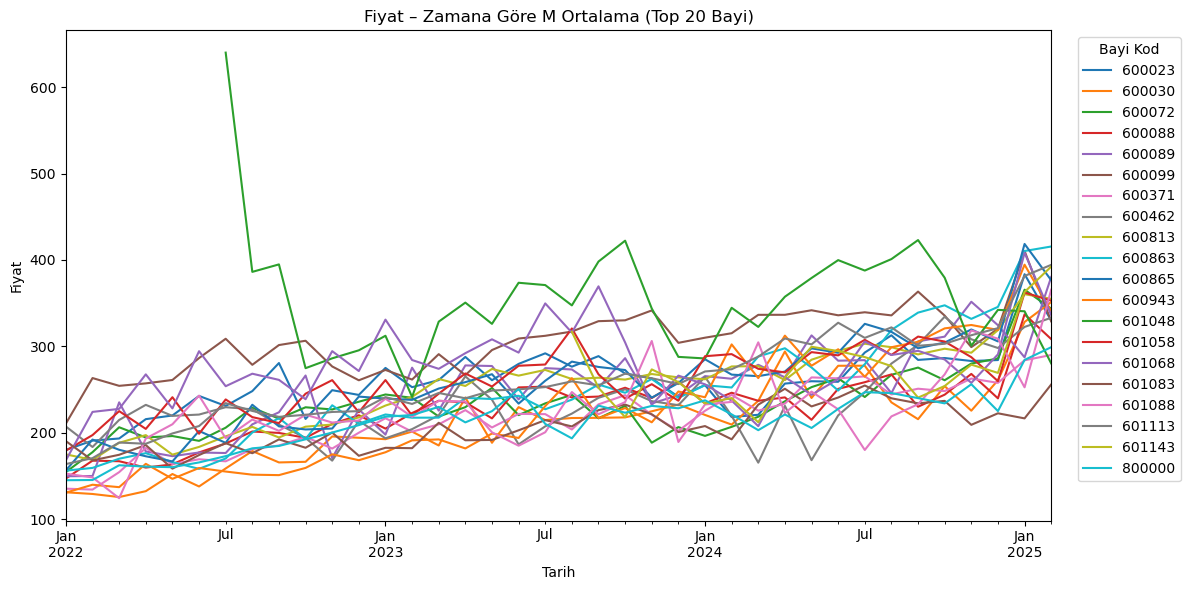

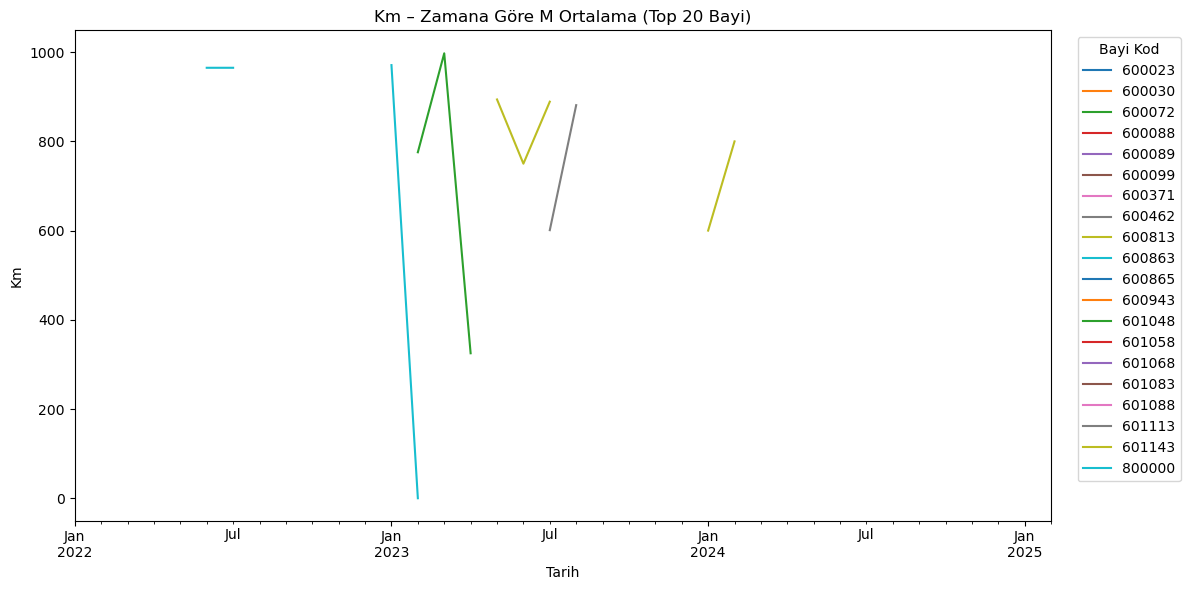

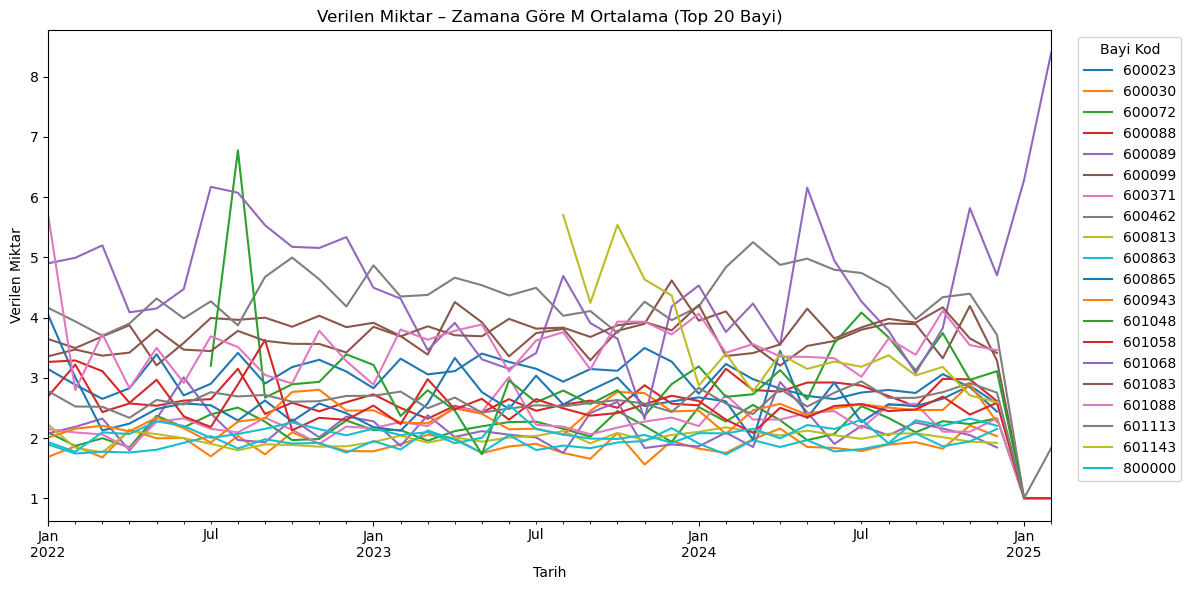

In [338]:
import pandas as pd
import matplotlib.pyplot as plt
import unicodedata as ud

# -------------------------------------------------
# 1) Başlıkları normalize et
# -------------------------------------------------
df_otob.columns = df_otob.columns.map(lambda s: ud.normalize("NFKC", s).strip())

# -------------------------------------------------
# 2) En yaygın 20 Bayi Kod
# -------------------------------------------------
top_n = 20
bayi_top = (
    df_otob["Bayi Kod"]
      .value_counts()
      .head(top_n)
      .index
      .tolist()
)

df_top = df_otob[df_otob["Bayi Kod"].isin(bayi_top)].copy()

# -------------------------------------------------
# 3) Datetime sütunlarını bul ve parse et
# -------------------------------------------------
date_keywords = ["tarih", "date", "time", "zaman"]
date_cols = [
    c for c in df_top.columns
    if any(k in c.lower() for k in date_keywords)
]

parsed_cols = []
for col in date_cols:
    df_top[col] = pd.to_datetime(df_top[col], errors="coerce", dayfirst=True)
    if pd.api.types.is_datetime64_any_dtype(df_top[col]):
        parsed_cols.append(col)

if not parsed_cols:
    raise ValueError("Tarih sütunu bulunamadı. Başlıkları kontrol edin.")

# En dolu tarih sütununu seç
date_col = max(parsed_cols, key=lambda c: df_top[c].notna().sum())

# -------------------------------------------------
# 4) Sayısal sütunlar
# -------------------------------------------------
num_cols = (
    df_top.select_dtypes(include="number")
          .columns.difference(["Bayi Kod"])
          .tolist()
)

# -------------------------------------------------
# 5) Zamana göre dağılım grafikleri (aylık ortalama)
# -------------------------------------------------
freq = "M"            # 'M' = aylık, 'W' = haftalık, 'Q' = çeyreklik

df_top = df_top.dropna(subset=[date_col]).set_index(date_col)

for ncol in num_cols:
    df_resampled = (
        df_top.groupby("Bayi Kod")[ncol]
              .resample(freq)
              .mean()
              .reset_index()
    )
    pivot = df_resampled.pivot(index=date_col, columns="Bayi Kod", values=ncol)
    
    plt.figure(figsize=(12, 6))
    pivot.plot(ax=plt.gca())
    plt.title(f"{ncol} – Zamana Göre {freq} Ortalama (Top {top_n} Bayi)")
    plt.ylabel(ncol)
    plt.xlabel("Tarih")
    plt.legend(title="Bayi Kod", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()



#### İ.E.Tip

In [359]:
df_otob[df_otob["İ.E.Tip"]=="A"]

,Bayi Kod,Çıkış Tarihi,Şase No,Km,İş Emri,İ.E.Tip,Parça Kodu,Temsa / Temsa dışı,Temsa Kodu,Temsa Güncel Kod,Garanti Dışı,Verilen Miktar,Fiyat,Firma Adı,Bayi Adı,Model Kod,Model Yıl,Ana Model,Unnamed: 18,Model Adı,Giriş Tarihi,Yıl,Ay,Plaka
0,600023,2022-06-30,NLTNVSF6L01000162,NaN,236019,A,0001231016-ALT,TEMSA DIŞI,0001231016,0001231016,Garanti Dışı,1.0,NaN,SVS TAŞIMACILIK ARAÇ KİRALAMA TİCARET,ATASER,OBAVE02,2012,AVENUE,NaN,AVENUE LF,2022-06-28,2022,Haziran,34HK3373
2,601083,2023-02-15,NLTRHUA8L01010133,NaN,65095,A,0001261069,TEMSA,NaN,0001261069,Garanti Dışı,1.0,NaN,ÇETUR ÇELEBİ TURİZM İNŞAAT SAN. VE TİC.A.Ş.,TAŞMER OTOMOTİV,OBSAF45,2013,SAFIR,NaN,SAFIR 13M DAF E5 410PS CS ORME,2023-02-15,2023,Şubat,07AVC216
3,601058,2024-08-15,NLTRHUA8L01010468,NaN,3619,A,0001261085,TEMSA,NaN,0001261085,Garanti Dışı,1.0,NaN,METRO TURİZM SEYAHAT ORGANİZASYON,ÖZPAM MUĞLA,OBSAF68,2015,SAFIR,NaN,SAFIR VIP 13 DAF E5 410PS CS DÜZTABAN,2024-01-08,2024,Ocak,34BK6820
4,600865,2023-08-02,NLTRJU98L01010089,NaN,30207,A,0001261087,TEMSA,NaN,0001261087,Garanti Dışı,1.0,NaN,DEVALP TURİZM TAŞIMACILIK KURUMSAL HİZMETLER,ASKAR BURSA,OBSAF22,2010,SAFİR,NaN,SAFIR 13 DAF E4 410PS SS ÖRME YURT İÇİ,2023-08-01,2023,Ağustos,16S2540
6,600023,2023-07-04,NLTNVSF6L01000770,NaN,239870,A,0001263006-ALT,TEMSA DIŞI,0001263006,0001263006,Garanti Dışı,1.0,NaN,DUDU VURAL,ATASER,OBAVE16,2014,AVENUE,NaN,AVENUE LF 12M CUMMINS E5 285PS,2023-07-03,2023,Temmuz,34HO2547
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
655000,601058,2025-03-12,NLTRTUK8L01000147,NaN,4780,A,D2000085-ALT01,TEMSA DIŞI,D2000085,D2000085,Garanti Dışı,NaN,NaN,ARVEM FARMA SAĞLIK MEDİKAL GIDA TEKSTİL,ÖZPAM MUĞLA,OBMAR11,2017,MARATON,NaN,MARATON 13 DAF E6 435PS/320KW CS,2025-02-24,2025,Şubat,20AJB907
655001,601058,2025-03-12,NLTRTUK8L01000147,NaN,4780,A,D2203568-ALT01,TEMSA DIŞI,D2203568,D2203568,Garanti Dışı,1.0,NaN,ARVEM FARMA SAĞLIK MEDİKAL GIDA TEKSTİL,ÖZPAM MUĞLA,OBMAR11,2017,MARATON,NaN,MARATON 13 DAF E6 435PS/320KW CS,2025-02-24,2025,Şubat,20AJB907
655002,601058,2025-03-12,NLTRTUK8L01000147,NaN,4780,A,D2206218-ALT01,TEMSA DIŞI,D2206218,D2206218,Garanti Dışı,NaN,NaN,ARVEM FARMA SAĞLIK MEDİKAL GIDA TEKSTİL,ÖZPAM MUĞLA,OBMAR11,2017,MARATON,NaN,MARATON 13 DAF E6 435PS/320KW CS,2025-02-24,2025,Şubat,20AJB907
655003,601058,2025-03-12,NLTRTUK8L01000147,NaN,4780,A,D2317876-ALT01,TEMSA DIŞI,D2317876,D2317876,Garanti Dışı,NaN,NaN,ARVEM FARMA SAĞLIK MEDİKAL GIDA TEKSTİL,ÖZPAM MUĞLA,OBMAR11,2017,MARATON,NaN,MARATON 13 DAF E6 435PS/320KW CS,2025-02-24,2025,Şubat,20AJB907


------ Çapraz Tablo (Sayı) ------


Garanti Dışı,Garanti,Garanti Dışı,All
İ.E.Tip,,,
A,16871,458133,475004
B,271,34721,34992
D,1239,103544,104783
G,2695,2021,4716
H,4,10980,10984
K,233,16016,16249
M,1,19,20
P,39,150,189
Y,236,2707,2943



------ Çapraz Tablo (Yüzde) ------


Garanti Dışı,Garanti,Garanti Dışı,All
İ.E.Tip,,,
A,78.0,72.3,72.5
B,1.3,5.5,5.3
D,5.7,16.3,16.0
G,12.5,0.3,0.7
H,0.0,1.7,1.7
K,1.1,2.5,2.5
M,0.0,0.0,0.0
P,0.2,0.0,0.0
Y,1.1,0.4,0.4


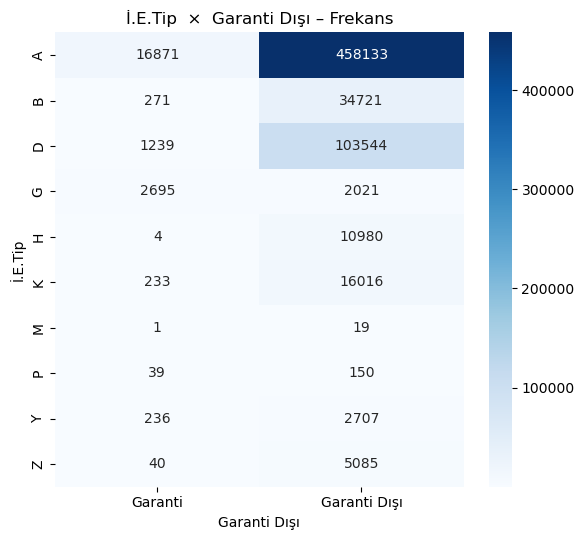

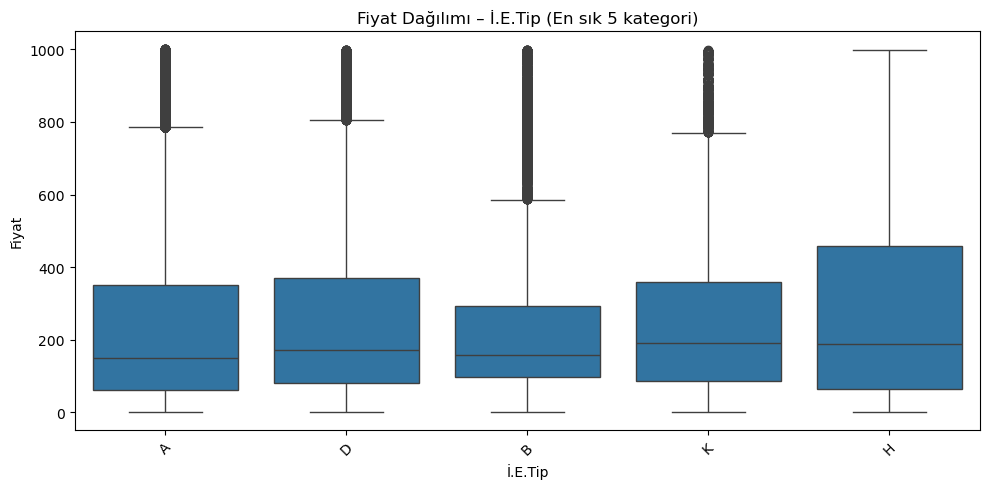

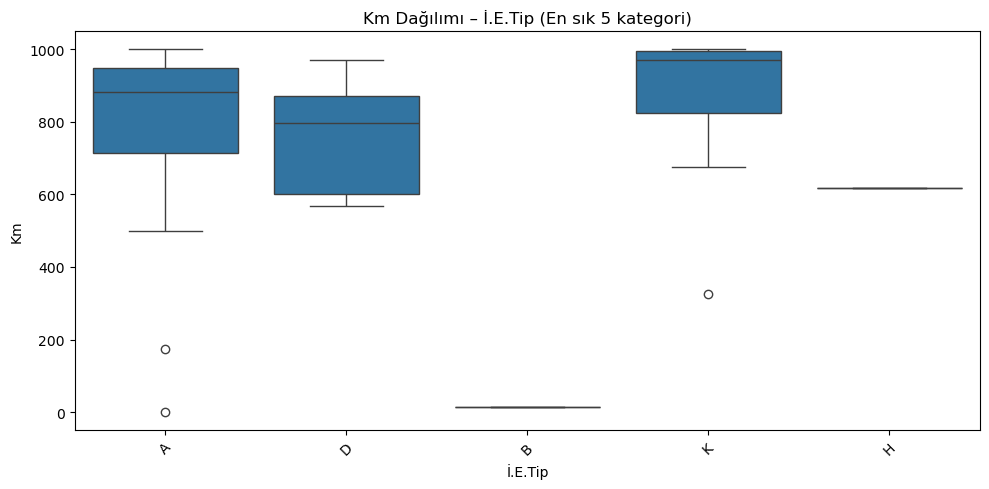

In [363]:
cat_col   = "İ.E.Tip"      # ← başka sütun görmek istersen değiştir
num_cols  = ["Fiyat", "Km"]  # numeric etki bakılacak sütunlar
top_k     = 5               # en sık kaç kategoriye yoğunlaşalım?

# -------------------------------------------------
# 1) Çapraz tablo (count + yüzde)
# -------------------------------------------------
ct = pd.crosstab(df_otob[cat_col], df_otob["Garanti Dışı"], margins=True)
pct = ct.div(ct.loc["All"], axis=1).round(3) * 100        # yüzde hesabı

print("------ Çapraz Tablo (Sayı) ------")
display(ct)
print("\n------ Çapraz Tablo (Yüzde) ------")
display(pct)

# -------------------------------------------------
# 2) Isı haritası ile görselleştir
# -------------------------------------------------
plt.figure(figsize=(6, 0.5 * len(ct)))
sns.heatmap(ct.iloc[:-1, :-1], annot=True, fmt="d", cmap="Blues")
plt.title(f"{cat_col}  ×  Garanti Dışı – Frekans")
plt.tight_layout()
plt.show()

# -------------------------------------------------
# 3) İlk top_k kategori için boxplot (Fiyat, Km…)
# -------------------------------------------------
top_categories = (
    df_otob[cat_col].value_counts()
           .head(top_k)
           .index
           .tolist()
)

df_sub = df_otob[df_otob[cat_col].isin(top_categories)]

for ncol in num_cols:
    plt.figure(figsize=(10, 5))
    sns.boxplot(
        data=df_sub,
        x=cat_col, y=ncol,
        order=top_categories
    )
    plt.title(f"{ncol} Dağılımı – {cat_col} (En sık {top_k} kategori)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Temsa kodu/güncel temsa kodu

In [376]:
mask = (
    df_otob["Temsa Kodu"].notna() &
    df_otob["Temsa Güncel Kod"].notna() &
    df_otob["Temsa Kodu"].astype(str).eq(df_otob["Temsa Güncel Kod"].astype(str))
)

df_equal = df_otob.loc[mask]


In [404]:
df_equal

,Bayi Kod,Çıkış Tarihi,Şase No,Km,İş Emri,İ.E.Tip,Parça Kodu,Temsa / Temsa dışı,Temsa Kodu,Temsa Güncel Kod,Garanti Dışı,Verilen Miktar,Fiyat,Firma Adı,Bayi Adı,Model Kod,Model Yıl,Ana Model,Unnamed: 18,Model Adı,Giriş Tarihi,Yıl,Ay,Plaka
0,600023,2022-06-30,NLTNVSF6L01000162,NaN,236019,A,0001231016-ALT,TEMSA DIŞI,0001231016,0001231016,Garanti Dışı,1.0,NaN,SVS TAŞIMACILIK ARAÇ KİRALAMA TİCARET,ATASER,OBAVE02,2012,AVENUE,NaN,AVENUE LF,2022-06-28,2022,Haziran,34HK3373
1,600023,2023-05-24,NLTNVSF6L01000090,NaN,239424,Y,0001231016-ALT,TEMSA DIŞI,0001231016,0001231016,Garanti Dışı,1.0,NaN,COŞKUNLAR HALK OTOBÜS İŞLETMECİLİĞİ,ATASER,OBAVE02,2012,AVENUE,NaN,AVENUE LF,2023-05-18,2023,Mayıs,34HO2476
5,600023,2022-10-13,NLTNVSF6L01000849,NaN,237114,Y,0001263006-ALT,TEMSA DIŞI,0001263006,0001263006,Garanti Dışı,1.0,NaN,İLYAS BALCI,ATASER,OBAVE12,2014,AVENUE,NaN,AVENUE LF 12M CUMMINS E5 285PS,2022-10-13,2022,Ekim,34NK2555
6,600023,2023-07-04,NLTNVSF6L01000770,NaN,239870,A,0001263006-ALT,TEMSA DIŞI,0001263006,0001263006,Garanti Dışı,1.0,NaN,DUDU VURAL,ATASER,OBAVE16,2014,AVENUE,NaN,AVENUE LF 12M CUMMINS E5 285PS,2023-07-03,2023,Temmuz,34HO2547
7,600023,2023-07-11,NLTNVSF6L01000171,NaN,240010,Y,0001263006-ALT,TEMSA DIŞI,0001263006,0001263006,Garanti Dışı,1.0,NaN,NOVA TUR TAŞIMACILIK OTOMOTİV SANAYİ VE,ATASER,OBAVE02,2012,AVENUE,NaN,AVENUE LF,2023-07-11,2023,Temmuz,34HO2543
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
655000,601058,2025-03-12,NLTRTUK8L01000147,NaN,4780,A,D2000085-ALT01,TEMSA DIŞI,D2000085,D2000085,Garanti Dışı,NaN,NaN,ARVEM FARMA SAĞLIK MEDİKAL GIDA TEKSTİL,ÖZPAM MUĞLA,OBMAR11,2017,MARATON,NaN,MARATON 13 DAF E6 435PS/320KW CS,2025-02-24,2025,Şubat,20AJB907
655001,601058,2025-03-12,NLTRTUK8L01000147,NaN,4780,A,D2203568-ALT01,TEMSA DIŞI,D2203568,D2203568,Garanti Dışı,1.0,NaN,ARVEM FARMA SAĞLIK MEDİKAL GIDA TEKSTİL,ÖZPAM MUĞLA,OBMAR11,2017,MARATON,NaN,MARATON 13 DAF E6 435PS/320KW CS,2025-02-24,2025,Şubat,20AJB907
655002,601058,2025-03-12,NLTRTUK8L01000147,NaN,4780,A,D2206218-ALT01,TEMSA DIŞI,D2206218,D2206218,Garanti Dışı,NaN,NaN,ARVEM FARMA SAĞLIK MEDİKAL GIDA TEKSTİL,ÖZPAM MUĞLA,OBMAR11,2017,MARATON,NaN,MARATON 13 DAF E6 435PS/320KW CS,2025-02-24,2025,Şubat,20AJB907
655003,601058,2025-03-12,NLTRTUK8L01000147,NaN,4780,A,D2317876-ALT01,TEMSA DIŞI,D2317876,D2317876,Garanti Dışı,NaN,NaN,ARVEM FARMA SAĞLIK MEDİKAL GIDA TEKSTİL,ÖZPAM MUĞLA,OBMAR11,2017,MARATON,NaN,MARATON 13 DAF E6 435PS/320KW CS,2025-02-24,2025,Şubat,20AJB907


In [422]:

df_equal[["Temsa Kodu", "Temsa Güncel Kod"]]




,Temsa Kodu,Temsa Güncel Kod
0,0001231016,0001231016
1,0001231016,0001231016
5,0001263006,0001263006
6,0001263006,0001263006
7,0001263006,0001263006
...,...,...
655000,D2000085,D2000085
655001,D2203568,D2203568
655002,D2206218,D2206218
655003,D2317876,D2317876


In [426]:
 df_otob["Temsa Kodu"].notna().count()

655005

In [428]:
df_equal["Temsa Kodu"].count()

143032

In [430]:
655005-143032

511973

#### Soru) 655 bin satırda 511973 bin temsa kodu, temsa güncel kodla farklıyken 143032 adedi hiç değişmemiştir.Bu kodlar ne anlama gelmektedir? Kodun değişimisinden ne çıkarabiliriz

In [ ]:
soru

## Parça kodu

In [447]:
df_otob["Parça Kodu"].value_counts()

Parça Kodu
BLTSPRY3        6308
EKO-054Y-ALT    4082
QC000001        3842
ML242294Y       3670
GRES            3650
                ... 
MK526986Ç          1
D1734272Y          1
D1734003           1
MK527323           1
HD205199Y.         1
Name: count, Length: 30963, dtype: int64

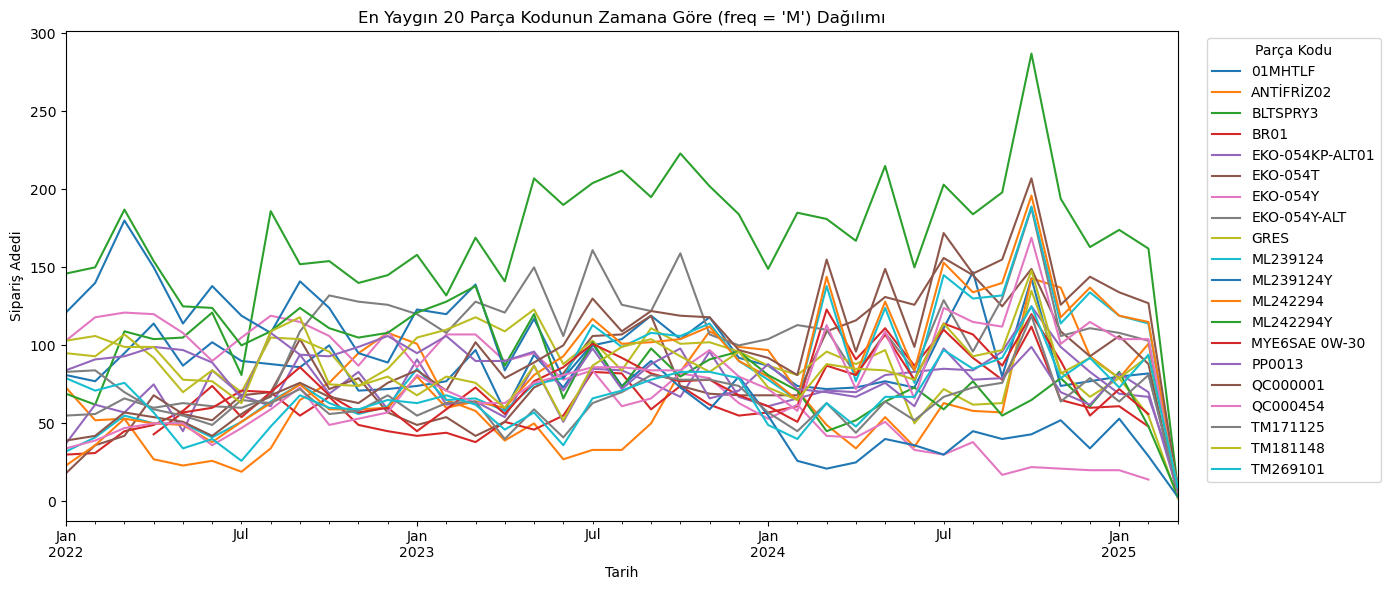

In [489]:
import pandas as pd
import matplotlib.pyplot as plt
import unicodedata as ud

# -------------------------------------------------
# 1) Başlıkları normalize et (gizli boşluk / Unicode)
# -------------------------------------------------
df_otob.columns = df_otob.columns.map(lambda s: ud.normalize("NFKC", s).strip())

# -------------------------------------------------
# 2) Tarih sütununu seç ve datetime'a çevir
#    (örnek: 'Çıkış Tarihi' yoksa 'Giriş Tarihi' vb. girin)
# -------------------------------------------------
date_col = "Çıkış Tarihi"          # ← gerekiyorsa değiştirin
df_otob[date_col] = pd.to_datetime(df_otob[date_col], errors="coerce", dayfirst=True)

if df_otob[date_col].isna().all():
    raise ValueError(f"'{date_col}' sütunu parse edilemedi; lütfen doğru tarih sütununu girin.")

# -------------------------------------------------
# 3) En yaygın 20 Parça Kodu
# -------------------------------------------------
top_n = 20
top_parts = (
    df_otob["Parça Kodu"]
      .value_counts()
      .head(top_n)
      .index
      .tolist()
)

df_top = df_otob[df_otob["Parça Kodu"].isin(top_parts)].copy()

# -------------------------------------------------
# 4) Zamana göre yeniden örnekleme ve pivot
# -------------------------------------------------
freq = "M"          # 'M' = aylık, 'W' = haftalık, 'Q' = çeyreklik …

df_top = df_top.dropna(subset=[date_col]).set_index(date_col)

df_resampled = (
    df_top.groupby("Parça Kodu")
          .resample(freq)
          .size()
          .reset_index(name="adet")
)

pivot = df_resampled.pivot(index=date_col, columns="Parça Kodu", values="adet")

# -------------------------------------------------
# 5) Grafik
# -------------------------------------------------
plt.figure(figsize=(14, 6))
pivot.plot(ax=plt.gca())
plt.title(f"En Yaygın {top_n} Parça Kodunun Zamana Göre (freq = '{freq}') Dağılımı")
plt.xlabel("Tarih")
plt.ylabel("Sipariş Adedi")
plt.legend(title="Parça Kodu", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## numeric veriler

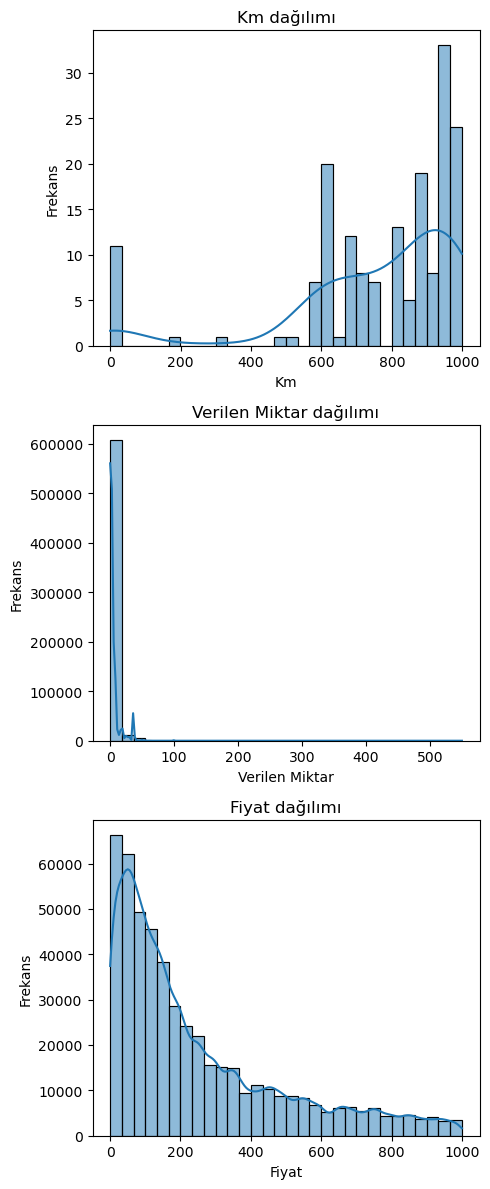

In [503]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------
# 1) Sayısal sütunları seç
# -------------------------------------------------
num_cols = df_otob.select_dtypes(include="number").columns.tolist()

if not num_cols:
    raise ValueError("DataFrame'de sayısal (int/float) sütun yok.")

# -------------------------------------------------
# 2) Her sütun için histogram + KDE
# -------------------------------------------------
n_cols = 1                                    # yatayda kaç grafik?
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 5, n_rows * 4),
                         squeeze=False)

for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df_otob[col].dropna(),
                 bins=30, kde=True, ax=ax)
    ax.set_title(f"{col} dağılımı")
    ax.set_xlabel(col)
    ax.set_ylabel("Frekans")

# Boş alt-eksenleri sil
for i in range(len(num_cols), n_rows * n_cols):
    fig.delaxes(axes.flatten()[i])

plt.tight_layout()
plt.show()


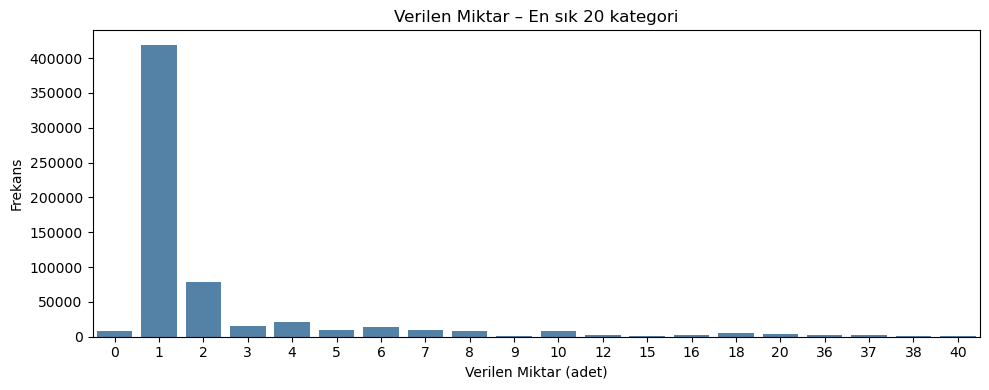

In [507]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# En sık görülen ilk 20 miktarı al – kuyruk karmaşasını azaltır
top_n = 20
vc = (
    df_otob["Verilen Miktar"]
      .dropna()
      .astype(int)                  # noktalı sayı varsa tamsayıya yuvarla
      .value_counts()
      .head(top_n)
      .sort_index()                 # 1,2,3… sıralansın
)

plt.figure(figsize=(10, 4))
sns.barplot(x=vc.index, y=vc.values, color="steelblue")
plt.title(f"Verilen Miktar – En sık {top_n} kategori")
plt.xlabel("Verilen Miktar (adet)")
plt.ylabel("Frekans")
plt.tight_layout()
plt.show()


### Zamana bağlı giriş çıkıç sayısı karşılaştırması

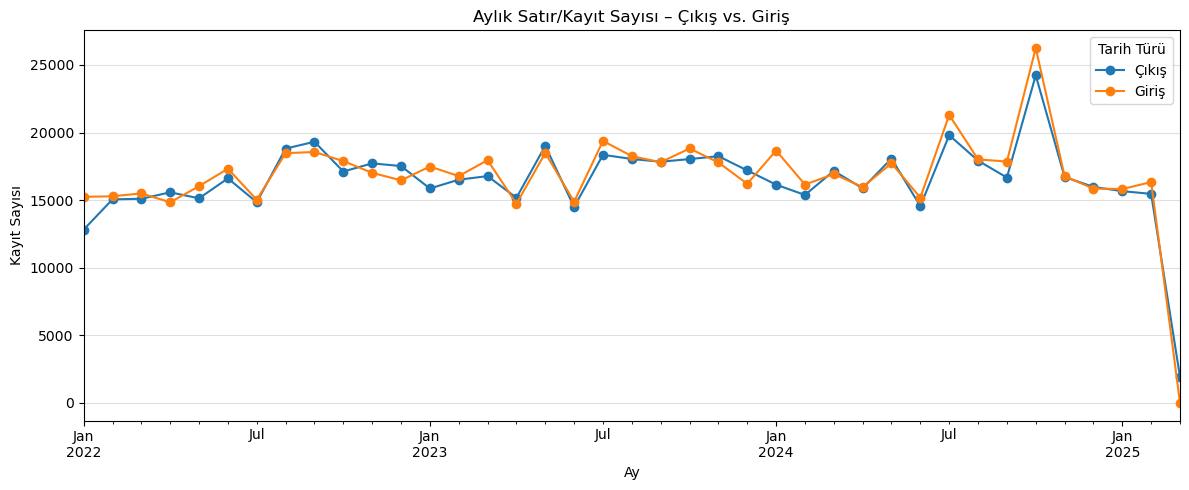

In [519]:
import pandas as pd
import matplotlib.pyplot as plt
import unicodedata as ud

# ――― 1) Başlıkları normalize et (gizli boşluk vs.) ―――
df_otob.columns = df_otob.columns.map(lambda s: ud.normalize("NFKC", s).strip())

# ――― 2) Tarih sütunlarını datetime'a çevir ―――
for col in ["Çıkış Tarihi", "Giriş Tarihi"]:
    df_otob[col] = pd.to_datetime(df_otob[col], errors="coerce", dayfirst=True)

# ――― 3) Aylık kayıt sayıları ―――
monthly_cikis = (
    df_otob.groupby(pd.Grouper(key="Çıkış Tarihi", freq="M"))
           .size()
           .rename("Çıkış")
)

monthly_giris = (
    df_otob.groupby(pd.Grouper(key="Giriş Tarihi", freq="M"))
           .size()
           .rename("Giriş")
)

# ――― 4) Birleştir ve çiz ―――
monthly_both = pd.concat([monthly_cikis, monthly_giris], axis=1).fillna(0)

plt.figure(figsize=(12, 5))
monthly_both.plot(ax=plt.gca(), marker="o")
plt.title("Aylık Satır/Kayıt Sayısı – Çıkış vs. Giriş")
plt.ylabel("Kayıt Sayısı")
plt.xlabel("Ay")
plt.grid(True, axis="y", alpha=0.4)
plt.legend(title="Tarih Türü")
plt.tight_layout()
plt.show()

## canter verisi

In [573]:
df_canter.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372396 entries, 0 to 372395
Data columns (total 40 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Kodu             372396 non-null  category      
 1   Adı              372396 non-null  category      
 2   İş Emri Tar.     372396 non-null  datetime64[ns]
 3   Kapanış Tar.     371026 non-null  datetime64[ns]
 4   İş Emri No       372396 non-null  category      
 5   Durum            372396 non-null  category      
 6   KM               372396 non-null  category      
 7   İş Emrini Açan   372396 non-null  category      
 8   Mess Üyesi       372396 non-null  category      
 9   Adı.1            372396 non-null  category      
 10  Telefon          288294 non-null  category      
 11  TCKN/VKN         371517 non-null  category      
 12  Model Adı        369010 non-null  category      
 13  Model Yılı       372396 non-null  category      
 14  İşlem Türü       372

In [552]:
df_canter

,Kodu,Adı,İş Emri Tar.,Kapanış Tar.,İş Emri No,Durum,KM,İş Emrini Açan,Mess Üyesi,Adı.1,Telefon,TCKN/VKN,Model Adı,Model Yılı,İşlem Türü,Kaynak,İşlem Kodu,Güncel Kod,Açıklama,Birim Fiyat,Miktar,İndirim,Tutar,Kmp. No,Bakım ?,Fatura ?,Filo ?,E.S ?,Personel Adı,Teknisten Adı,Fatura Türü,Kategori,Şasi,Plaka,Motor No,Temsa Aracı mı?,Teslim Alan,Telefon.1,Garantide mi?,Unnamed: 39
0,600030,Bayraktar,1.01.2022,1.01.2022,101465,Kapalı,182104,FATMA CİHAN,False,ÜÇYILDIZ MOBİLYA İMALAT İTHALAT İHRACAT SAN.VE TİC.LTD.ŞTİ.,905495485461.0,9050236374.0,CANTER,2015,Parça,Temsa Dışı,MY5W30C2,MY5W30C2,5W30 MOTOR YAĞI,₺80.00,6.5,0.0,₺520.00,NaN,False,True,False,False,NaN,NaN,Müşteri,Mekanik,NLTFEB21C01000536,54BF351,2357529,Temsa Aracı,AYDIN BAŞARAN,905495485461,Hayır,NaN
1,600030,Bayraktar,1.01.2022,1.01.2022,101465,Kapalı,182104,FATMA CİHAN,False,ÜÇYILDIZ MOBİLYA İMALAT İTHALAT İHRACAT SAN.VE TİC.LTD.ŞTİ.,905495485461.0,9050236374.0,CANTER,2015,Parça,Temsa,QC000001Y,QC000001Y,"FILTRE, YAG",₺74.45,1.0,10.0,₺67.00,NaN,False,True,False,False,NaN,NaN,Müşteri,Mekanik,NLTFEB21C01000536,54BF351,2357529,Temsa Aracı,AYDIN BAŞARAN,905495485461,Hayır,NaN
2,600030,Bayraktar,1.01.2022,1.01.2022,101465,Kapalı,182104,FATMA CİHAN,False,ÜÇYILDIZ MOBİLYA İMALAT İTHALAT İHRACAT SAN.VE TİC.LTD.ŞTİ.,905495485461.0,9050236374.0,CANTER,2015,Parça,Temsa Dışı,ML239124.,ML239124.,"FİLTRE, YAKIT",₺110.19,1.0,10.0,₺99.17,NaN,False,True,False,False,NaN,NaN,Müşteri,Mekanik,NLTFEB21C01000536,54BF351,2357529,Temsa Aracı,AYDIN BAŞARAN,905495485461,Hayır,NaN
3,600030,Bayraktar,1.01.2022,1.01.2022,101465,Kapalı,182104,FATMA CİHAN,False,ÜÇYILDIZ MOBİLYA İMALAT İTHALAT İHRACAT SAN.VE TİC.LTD.ŞTİ.,905495485461.0,9050236374.0,CANTER,2015,Parça,Temsa Dışı,ML242294.,ML242294.,HAVA FİLTRESİ,₺263.60,1.0,9.9,₺237.50,NaN,False,True,False,False,NaN,NaN,Müşteri,Mekanik,NLTFEB21C01000536,54BF351,2357529,Temsa Aracı,AYDIN BAŞARAN,905495485461,Hayır,NaN
4,600030,Bayraktar,1.01.2022,4.01.2022,101464,Kapalı,384036,FATMA CİHAN,False,MEHTİ DUMAN,905352353928.0,34624629422.0,CANTER,2008,Parça,Temsa,TE215002Y,TE215002Y,"FİLTRE,YAĞ",₺103.69,1.0,10.0,₺93.32,NaN,False,True,False,False,NaN,NaN,Müşteri,Mekanik,NLTFE85PG01001421,11AAK250,4D34-L51783,Temsa Aracı,İHSAN DUMAN,905352353928,Hayır,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372391,601109,Yıldızlar,28.02.2025,28.02.2025,110084,Kapalı,21089,MURAT ÇETİNDERE,False,ESLAB KAHVE GIDA SANAYİ VE TİCARET ANONİM ŞİRKETİ,905078746449.0,3800537841.0,CANTER,2024,Parça,Temsa Dışı,AMP1,NaN,AMPUL,₺125.00,4.0,5.0,₺475.00,NaN,False,True,False,False,NaN,NaN,Müşteri,Mekanik,NLTTECX1G01001927,34MEF141,4629085,Temsa Aracı,YILMAZ ÖZTÜRK,905384944336.0,Evet,NaN
372392,601109,Yıldızlar,28.02.2025,28.02.2025,110083,Kapalı,98195,MURAT ÇETİNDERE,False,BEDA ENERJİ DAĞITIM VE PERAKENDE SATIŞ HİZMETLERİ ANONİM ŞİRKETİ,905074255677.0,1600670174.0,CANTER,2021,Parça,Temsa Dışı,MK580527-ALT,NaN,FAR ÜSTÜ SİNYAL SOL,"₺1,500.00",1.0,10.0,"₺1,350.00",NaN,False,True,True,False,NaN,NaN,Müşteri,Mekanik,NLTTEB91G01000521,06CKZ884,4026366,Temsa Aracı,ÜMİT TOPRAK,905544840815.0,Hayır,NaN
372393,601109,Yıldızlar,28.02.2025,28.02.2025,110083,Kapalı,98195,MURAT ÇETİNDERE,False,BEDA ENERJİ DAĞITIM VE PERAKENDE SATIŞ HİZMETLERİ ANONİM ŞİRKETİ,905074255677.0,1600670174.0,CANTER,2021,Parça,Temsa,MK486111,NaN,AYNA ISITMALI,"₺2,880.71",1.0,10.0,"₺2,592.64",NaN,False,True,True,False,NaN,NaN,Müşteri,Mekanik,NLTTEB91G01000521,06CKZ884,4026366,Temsa Aracı,ÜMİT TOPRAK,905544840815.0,Hayır,NaN
372394,601109,Yıldızlar,28.02.2025,28.02.2025,110083,Kapalı,98195,MURAT ÇETİNDERE,False,BEDA ENERJİ DAĞITIM VE PERAKENDE SATIŞ HİZMETLERİ ANONİM ŞİRKETİ,905074255677.0,1600670174.0,CANTER,2021,Parça,Temsa,FE802165Y,NaN,E5 STOP SAĞ SOL,"₺2,925.88",2.0,10.0,"₺5,266.58",NaN,False,True,True,False,NaN,NaN,Müşteri,Mekanik,NLTTEB91G01000521,06CKZ884,4026366,Temsa Aracı,ÜMİT TOPRAK,905544840815.0,Hay

In [554]:
import pandas as pd
import unicodedata as ud

# -------------------------------------------------
# 1) Başlıkları normalize et (örneğin "İş Emri Tar. ")
# -------------------------------------------------
df_canter.columns = (
    df_canter.columns
          .map(lambda s: ud.normalize("NFKC", s).strip())
)

# -------------------------------------------------
# 2) Sütun listeleri
# -------------------------------------------------
date_cols   = ["İş Emri Tar.", "Kapanış Tar."]
numeric_cols = ["Birim Fiyat", "Tutar", "Miktar"]

# Gerçekten var olan başlıklara indirgeme (typo vs. önler)
date_cols   = [c for c in date_cols   if c in df_canter.columns]
numeric_cols = [c for c in numeric_cols if c in df_canter.columns]

# -------------------------------------------------
# 3) Dönüştür
# -------------------------------------------------
# Datetime
df_canter[date_cols] = df_canter[date_cols].apply(
    pd.to_datetime, errors="coerce", dayfirst=True
)

# Numeric
df_canter[numeric_cols] = df_canter[numeric_cols].apply(
    pd.to_numeric, errors="coerce"
)

# Category – geriye kalanlar
cat_cols = [c for c in df_canter.columns if c not in date_cols + numeric_cols]
df_canter[cat_cols] = df_canter[cat_cols].astype("category")

# -------------------------------------------------
# 4) Kontrol
# -------------------------------------------------
print("✓ Dönüşüm tamamlandı.\n")
print(df_canter.info())


✓ Dönüşüm tamamlandı.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372396 entries, 0 to 372395
Data columns (total 40 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Kodu             372396 non-null  category      
 1   Adı              372396 non-null  category      
 2   İş Emri Tar.     372396 non-null  datetime64[ns]
 3   Kapanış Tar.     371026 non-null  datetime64[ns]
 4   İş Emri No       372396 non-null  category      
 5   Durum            372396 non-null  category      
 6   KM               372396 non-null  category      
 7   İş Emrini Açan   372396 non-null  category      
 8   Mess Üyesi       372396 non-null  category      
 9   Adı.1            372396 non-null  category      
 10  Telefon          288294 non-null  category      
 11  TCKN/VKN         371517 non-null  category      
 12  Model Adı        369010 non-null  category      
 13  Model Yılı       372396 non-null  category      
 1

## canter eksik ve kategorik veri analizi

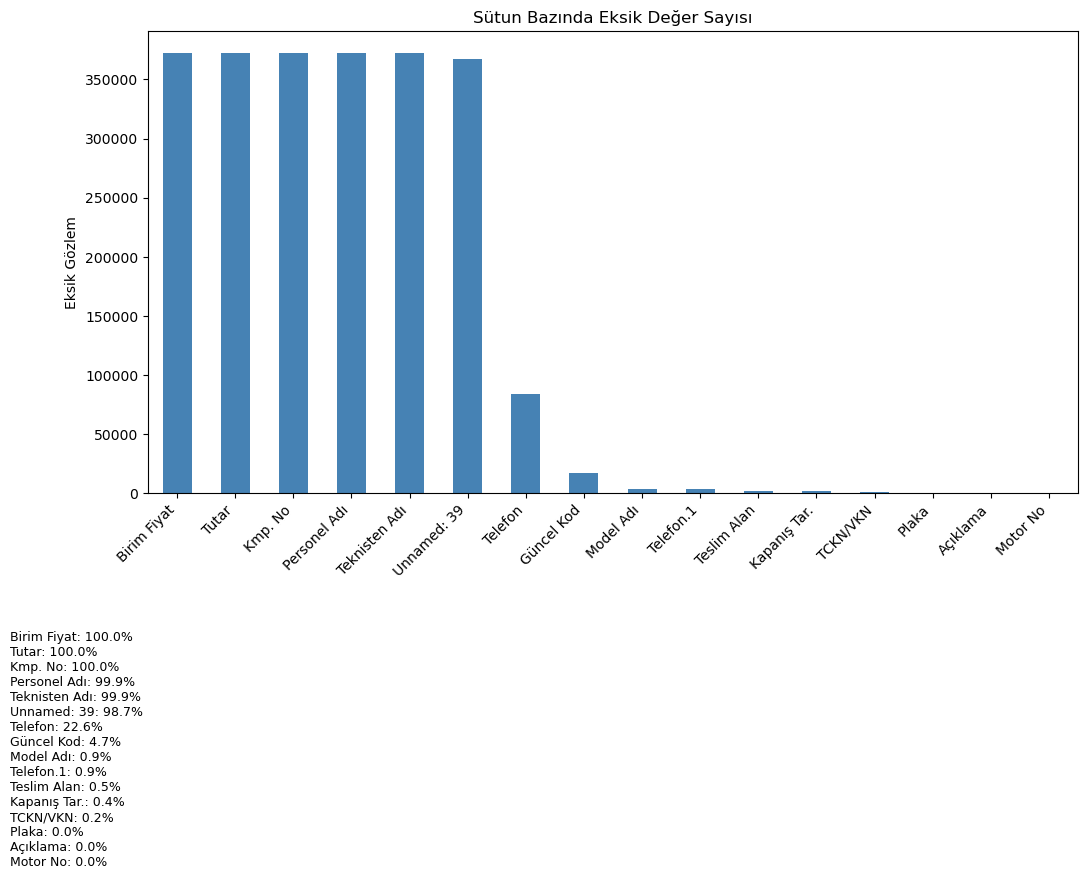

In [560]:
null_counts = df_canter.isna().sum()
null_perc   = null_counts / len(df_canter) * 100

null_stats = (
    pd.DataFrame({"Eksik Sayısı": null_counts, "Yüzde (%)": null_perc})
      .query("`Eksik Sayısı` > 0")                    # tamamen dolu sütunları at
      .sort_values("Eksik Sayısı", ascending=False)
)

# -------------------------------------------------
# 3) Grafik
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))
null_stats["Eksik Sayısı"].plot(kind="bar", ax=ax, color="steelblue")

ax.set_title("Sütun Bazında Eksik Değer Sayısı")
ax.set_ylabel("Eksik Gözlem")
ax.set_xticklabels(null_stats.index, rotation=45, ha="right")

# -------------------------------------------------
# 4) Yüzdeleri toplu hâlde grafiğin altına yaz
# -------------------------------------------------
# • Yazılacak metni satır satır oluştur
yuzde_metni = "\n".join(
    f"{col}: {pct:.1f}%" for col, pct in null_stats["Yüzde (%)"].items()
)

# • Figürün içine, grafiğin altına sola hizalı şekilde yerleştir
fig.text(0.01, -0.12, yuzde_metni, ha="left", va="top", fontsize=9)

plt.show()

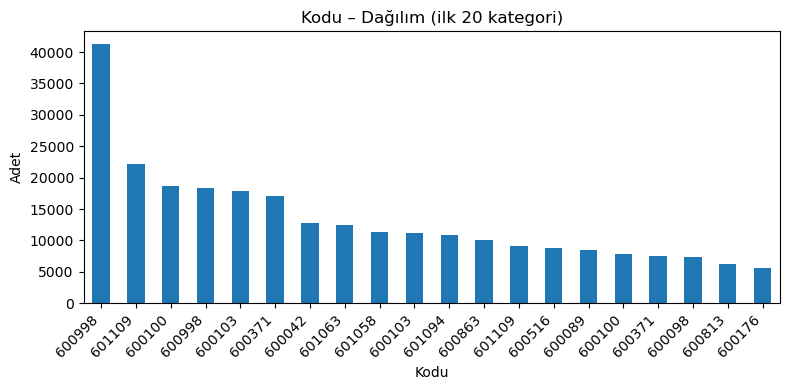

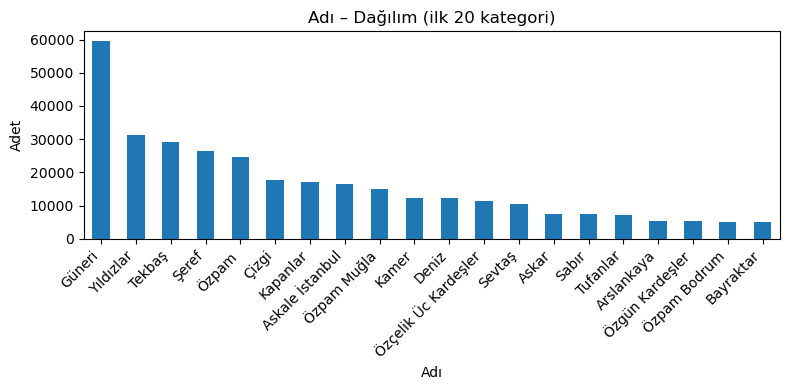

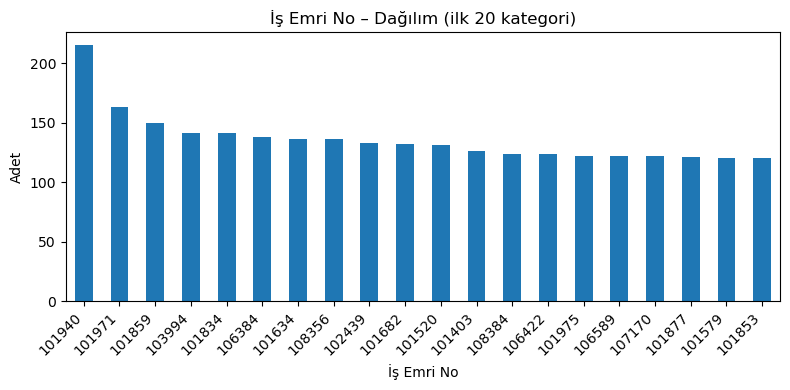

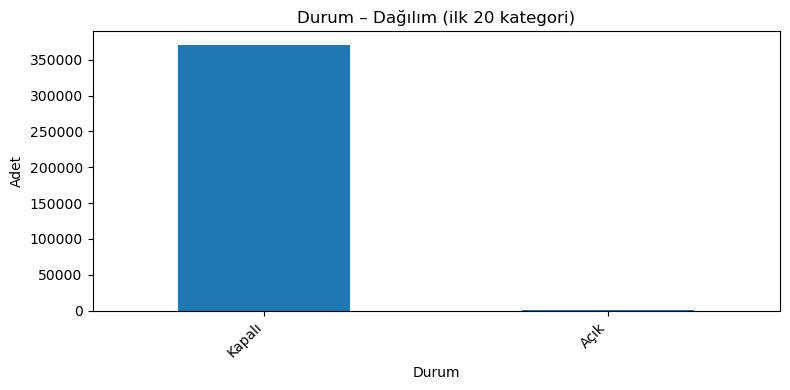

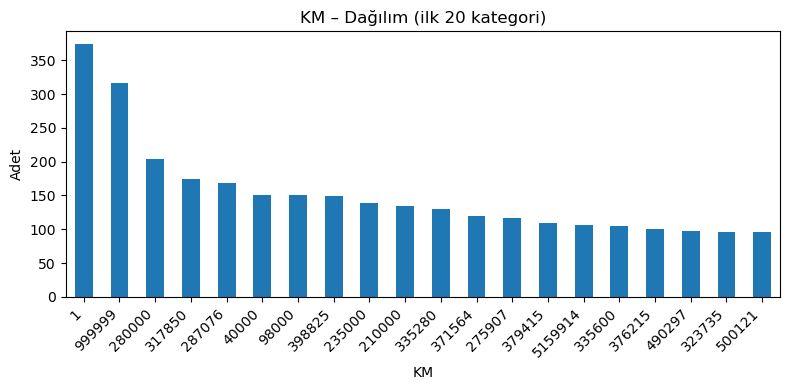

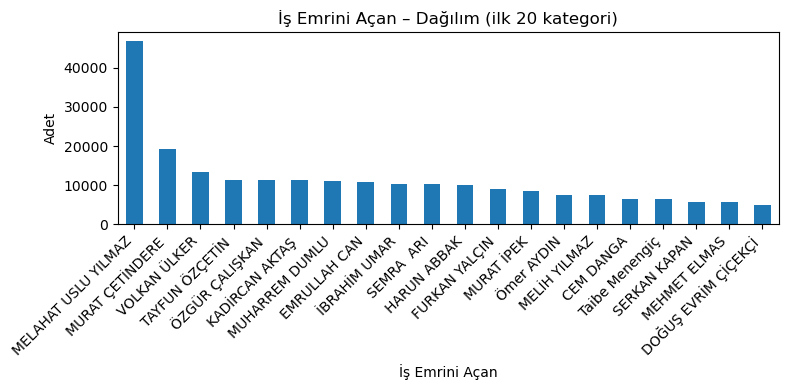

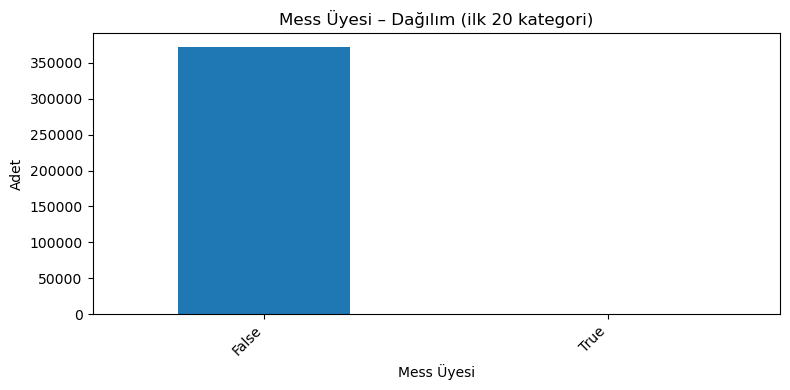

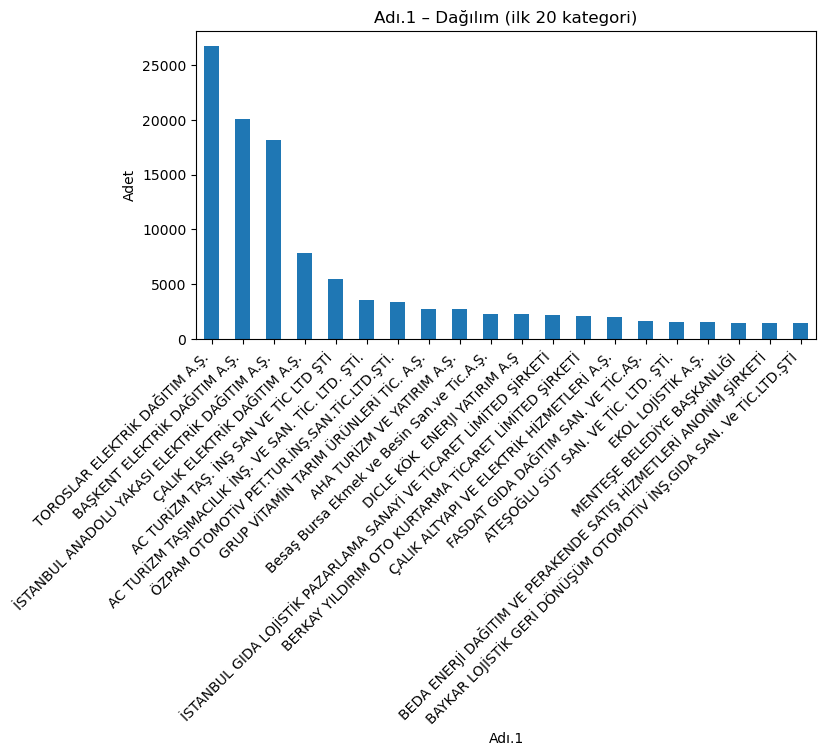

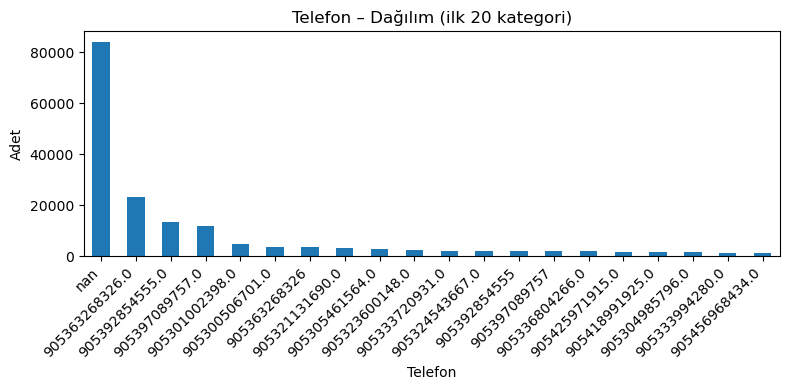

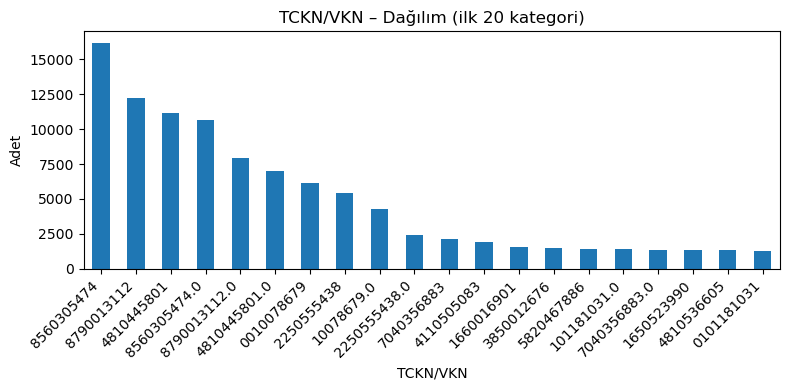

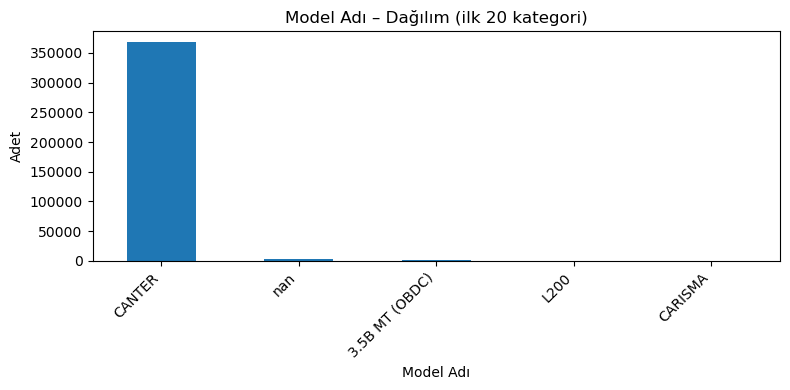

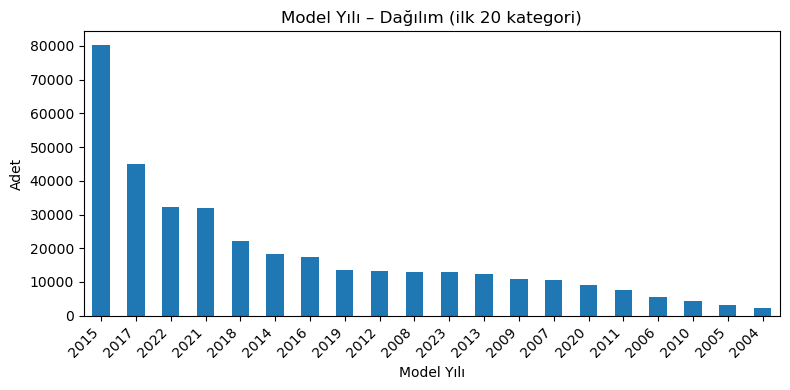

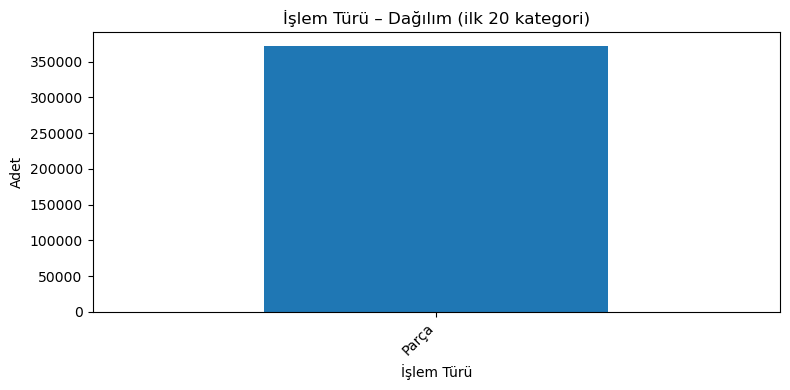

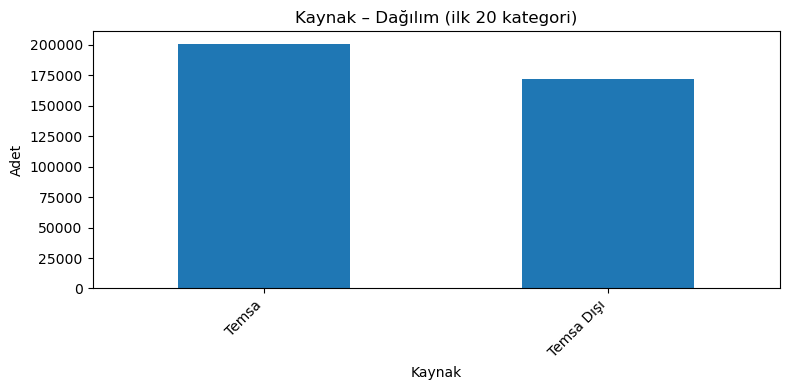

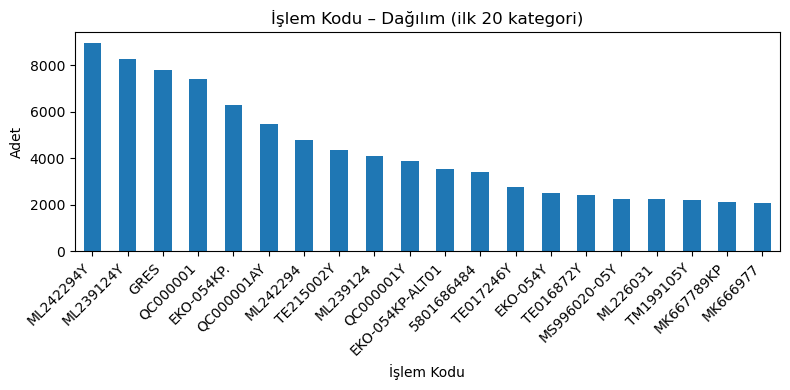

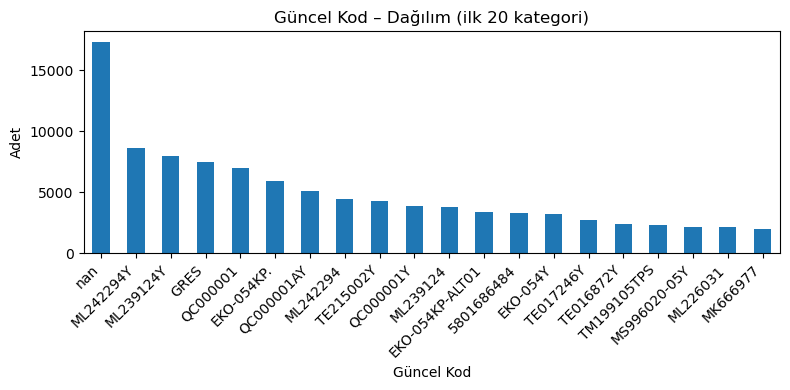

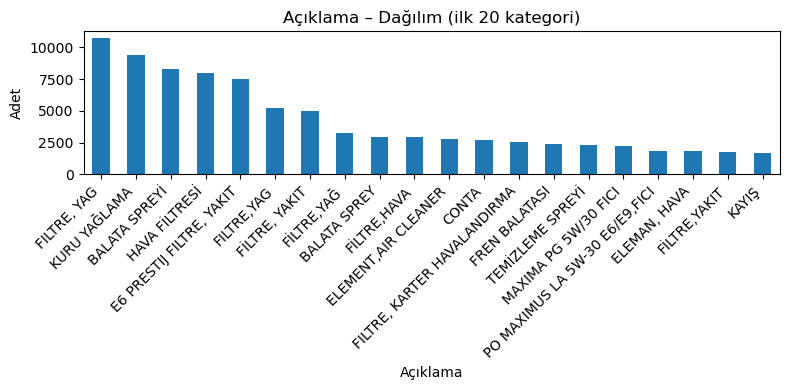

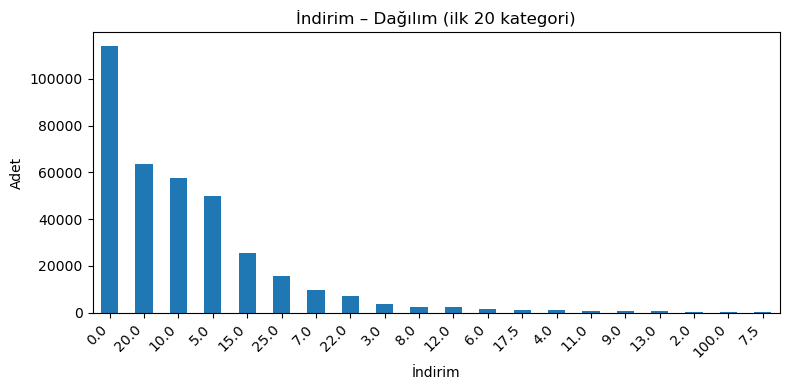

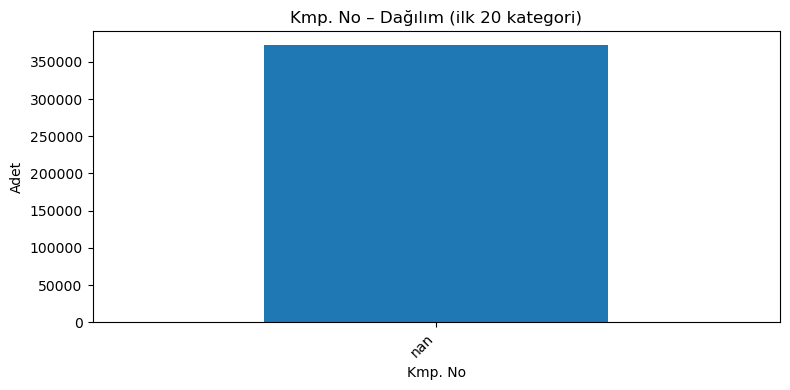

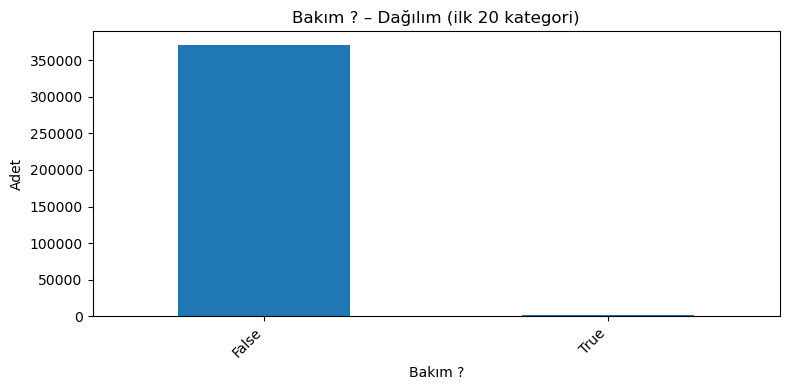

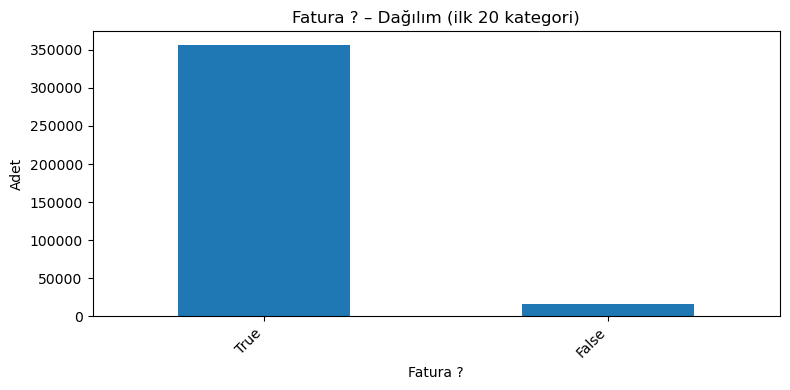

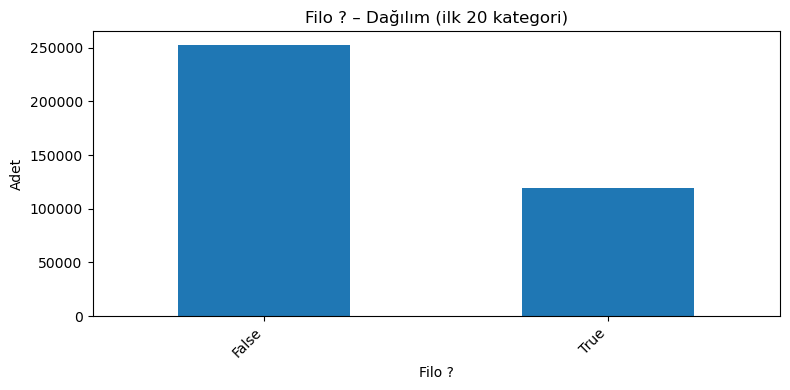

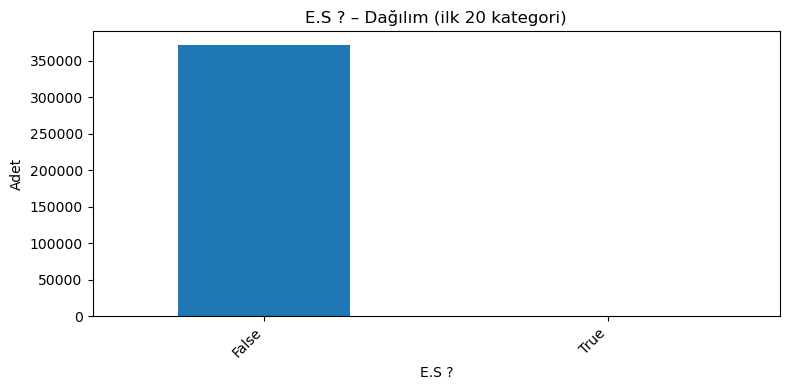

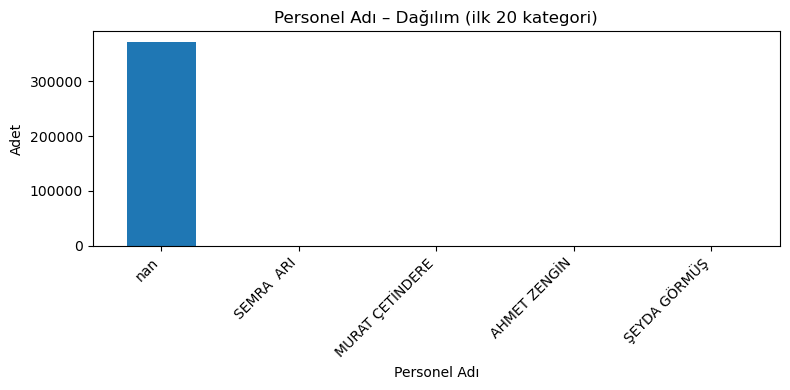

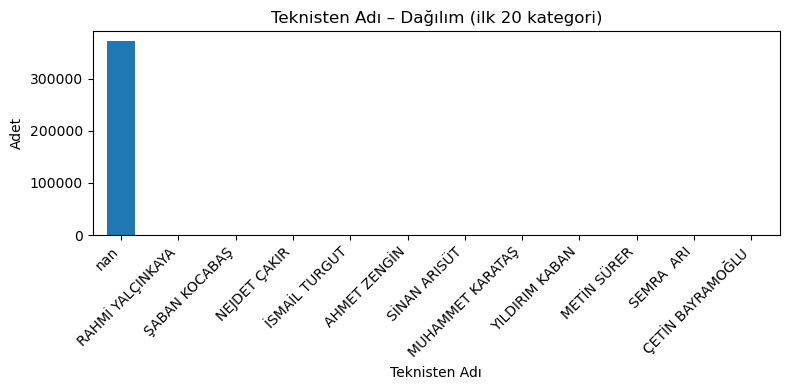

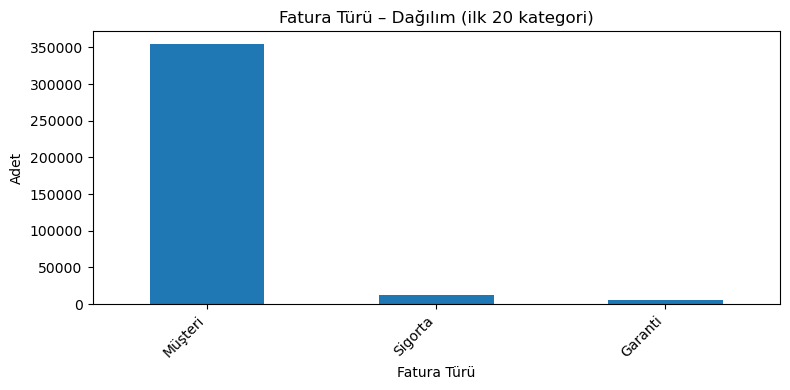

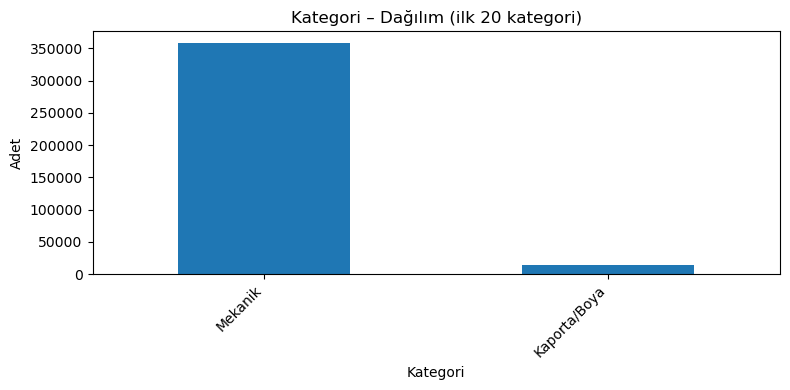

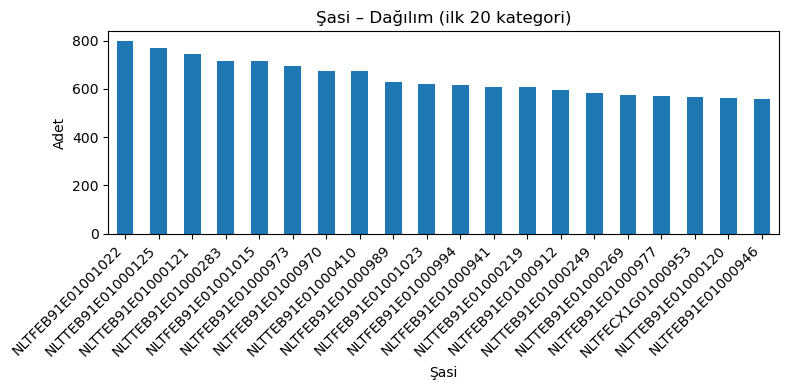

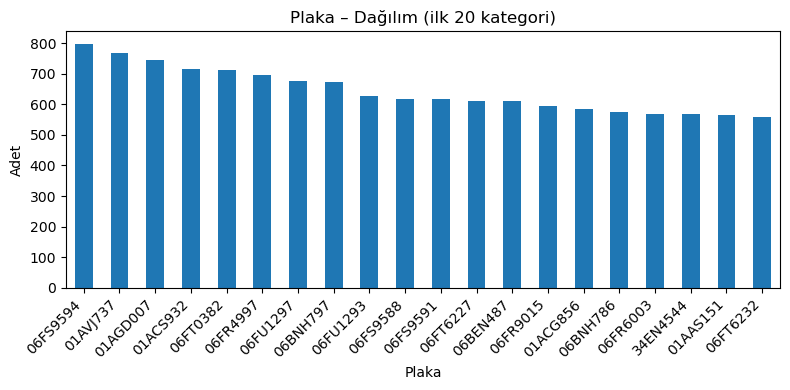

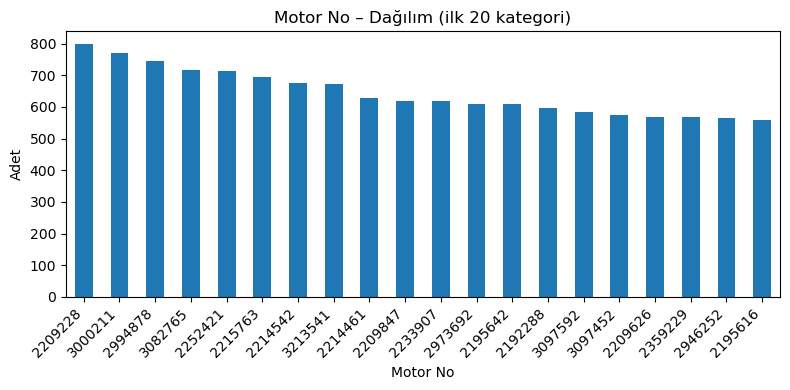

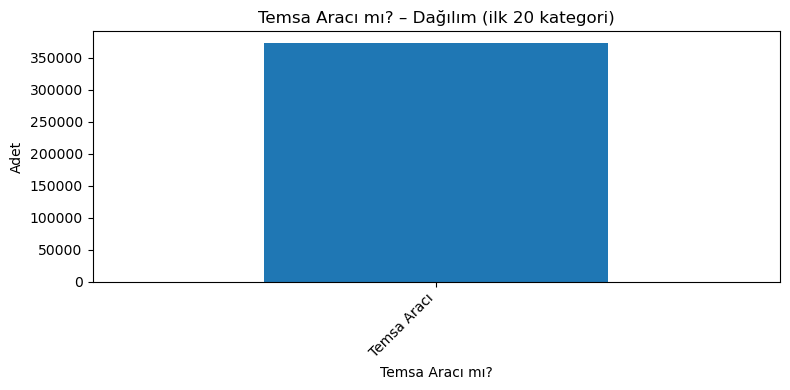

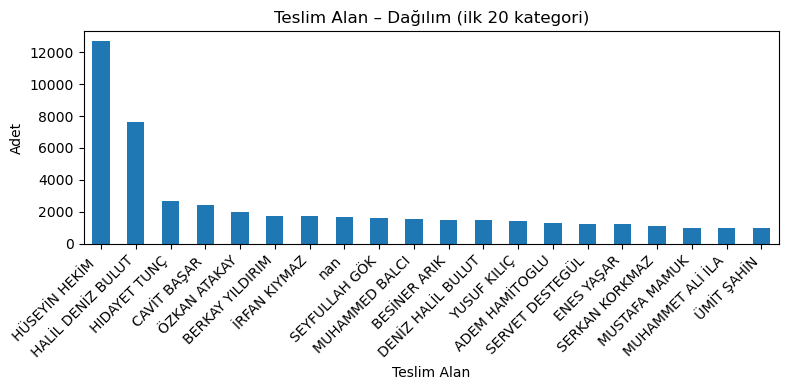

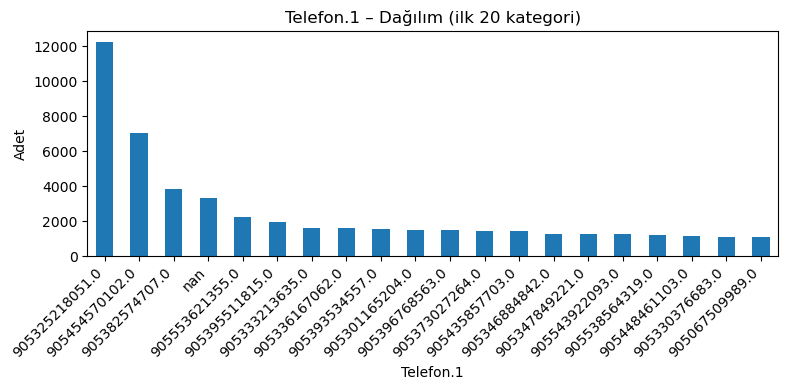

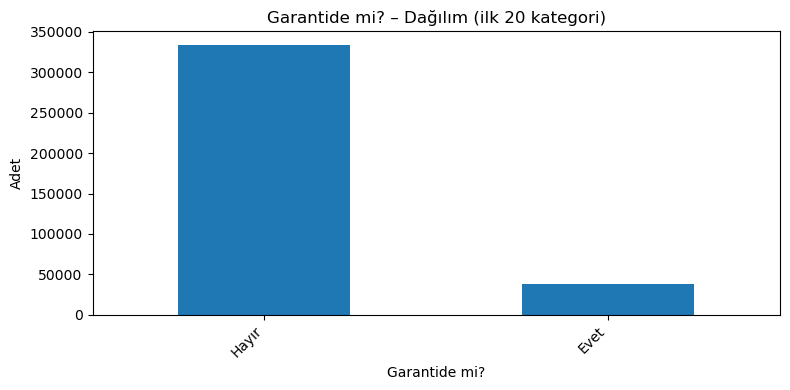

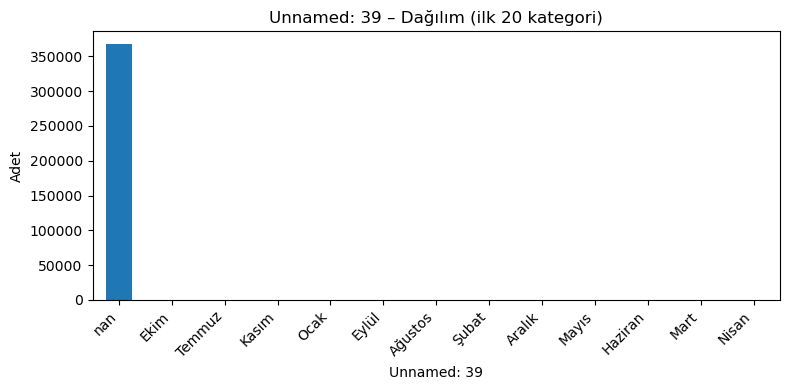

In [631]:

# -----------------------------------------
cat_cols = df_canter.select_dtypes(include=["category"]).columns.tolist()


# -----------------------------------------
# 2) Sırayla çiz
# -----------------------------------------
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    # Çok kalabalık kolonlar için en fazla ilk 20 kategoriyi çizdiriyoruz
    df_canter[col].value_counts(dropna=False).head(20).plot(kind="bar")
    plt.title(f"{col} – Dağılım (ilk 20 kategori)")
    plt.ylabel("Adet")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

#### kodu

In [603]:
df_canter.loc[df_canter["Kodu"]==601094,"İş Emrini Açan"].value_counts()

İş Emrini Açan
ÖZGÜR ÇALIŞKAN    6556
FURKAN ÇELEBİ     2329
CEM ÇALIŞKAN      1075
AYLİN ERDOĞAN      667
HASAN ÇELİK         91
                  ... 
FIRAT ÇETİNTAŞ       0
FUAT ODABAŞI         0
FULYA ZEYBEK         0
FURKAN YALÇIN        0
ŞULE ÖZĞEN           0
Name: count, Length: 216, dtype: int64

In [633]:
df_canter.iloc[0:1]

,Kodu,Adı,İş Emri Tar.,Kapanış Tar.,İş Emri No,Durum,KM,İş Emrini Açan,Mess Üyesi,Adı.1,Telefon,TCKN/VKN,Model Adı,Model Yılı,İşlem Türü,Kaynak,İşlem Kodu,Güncel Kod,Açıklama,Birim Fiyat,Miktar,İndirim,Tutar,Kmp. No,Bakım ?,Fatura ?,Filo ?,E.S ?,Personel Adı,Teknisten Adı,Fatura Türü,Kategori,Şasi,Plaka,Motor No,Temsa Aracı mı?,Teslim Alan,Telefon.1,Garantide mi?,Unnamed: 39
0,600030,Bayraktar,2022-01-01,2022-01-01,101465,Kapalı,182104,FATMA CİHAN,False,ÜÇYILDIZ MOBİLYA İMALAT İTHALAT İHRACAT SAN.VE TİC.LTD.ŞTİ.,905495485461.0,9050236374.0,CANTER,2015,Parça,Temsa Dışı,MY5W30C2,MY5W30C2,5W30 MOTOR YAĞI,NaN,6.5,0.0,NaN,NaN,False,True,False,False,NaN,NaN,Müşteri,Mekanik,NLTFEB21C01000536,54BF351,2357529,Temsa Aracı,AYDIN BAŞARAN,905495485461,Hayır,NaN


In [599]:
df_canter.loc[df_canter["Kodu"]==601094,"Adı"].value_counts()

Adı
Askale İstanbul             10913
Adnan Pazarlama (Servis)        0
Tufanlar                        0
Meteler                         0
Metsan                          0
Odabaşı                         0
Oto Burçak                      0
Oto Klinik                      0
Oto Yörükoglu                   0
Otomax                          0
Otosüper                        0
Sabır                           0
Sevtaş                          0
Tekbaş                          0
Yamaç                           0
Mapar                           0
Yıldızlar                       0
Çelikler                        0
Çizgi                           0
Örnek Oto                       0
Öz Kardeşler                    0
Özgün Kardeşler                 0
Özikizler Otomotiv              0
Özpam                           0
Özpam Bodrum                    0
Özpam Muğla                     0
Özçelik Üc Kardeşler            0
Mapar İzmir                     0
Kıvanç                          0
Aldatmaz  

In [645]:
df_canter.loc[df_canter["Kodu"]==601094,"Adı.1"].value_counts()

Adı.1
BEDA ENERJİ DAĞITIM VE PERAKENDE SATIŞ HİZMETLERİ ANONİM ŞİRKETİ     484
ARTESA KUMAŞ SAN VE DIŞ TİC ANM ŞTİ                                  187
RAMEKS YIKAMA APRE VE TEKSTİL SANAYİTİC LTD ŞTİ                      185
ZBC GIDA TURZ TEKS TİC TİC LTD ŞTİ                                   181
KARTES ÇELİK EŞYA SAN. VE TİC. LTD ŞTİ                               156
                                                                    ... 
FİKAR LOJİSTİK NAKLİYAT TEKSTİL SANAYİ VE TİCARET LİMİTED ŞİRKETİ      0
FİGEN KOCATEPE                                                         0
FİDES TEKNOLOJİ VE GÜVENLİK SİS.TİC.LTD.ŞTİ.                           0
FİDAN İNŞAAT A.Ş.                                                      0
şerif erol                                                             0
Name: count, Length: 7607, dtype: int64

In [647]:
df_canter.loc[df_canter["Kodu"]==601094,"TCKN/VKN"].value_counts()

TCKN/VKN
1600670174       305
1600670174.0     179
8260337065       162
9310056722       134
7340704718       124
                ... 
23774038802.0      0
23788795784.0      0
23791129026.0      0
23809219206.0      0
ewer               0
Name: count, Length: 10320, dtype: int64

In [649]:
df_canter.loc[df_canter["Kodu"]==601094,"Telefon"].value_counts()

Telefon
905447162942.0    447
905377823102.0    168
905332392066.0    150
905366003102.0    105
905327752503.0    103
                 ... 
905337367234.0      0
905337365856.0      0
905337363613.0      0
905337360680.0      0
905559886155        0
Name: count, Length: 7827, dtype: int64

### durum

In [623]:
df_canter.loc[df_canter["Durum"]=="Açık","Kapanış Tar."].describe()

count      0
mean     NaT
min      NaT
25%      NaT
50%      NaT
75%      NaT
max      NaT
Name: Kapanış Tar., dtype: object

In [625]:
df_canter.loc[df_canter["Durum"]=="Kapalı","Kapanış Tar."].describe()

count                           371026
mean     2023-08-02 16:08:07.469880576
min                2022-01-01 00:00:00
25%                2022-10-26 00:00:00
50%                2023-08-08 00:00:00
75%                2024-05-07 00:00:00
max                2025-03-19 00:00:00
Name: Kapanış Tar., dtype: object